### plot 2d plot and save npz, get min

Saved main NPZ to: C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data\CavitySpec_versus_flux_20260724_1248_to_20260724_1302_I.npz


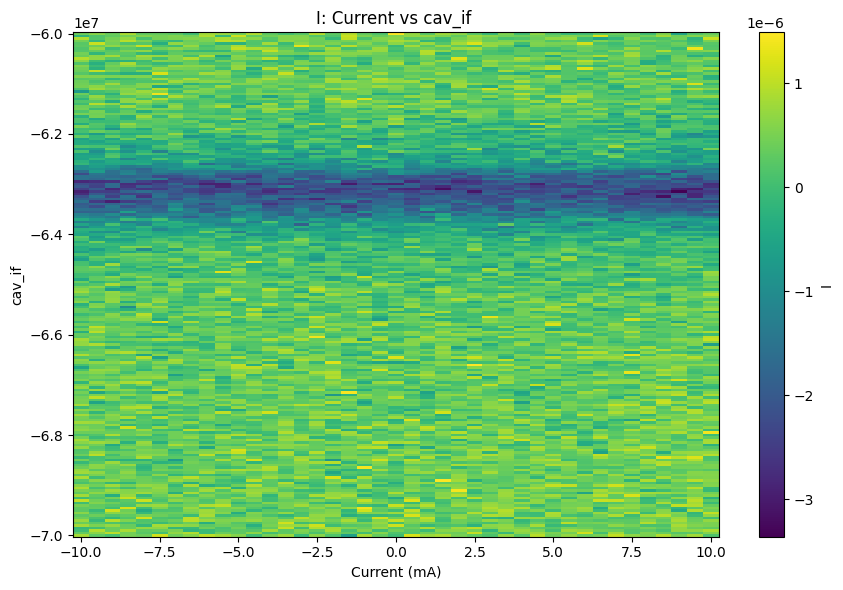

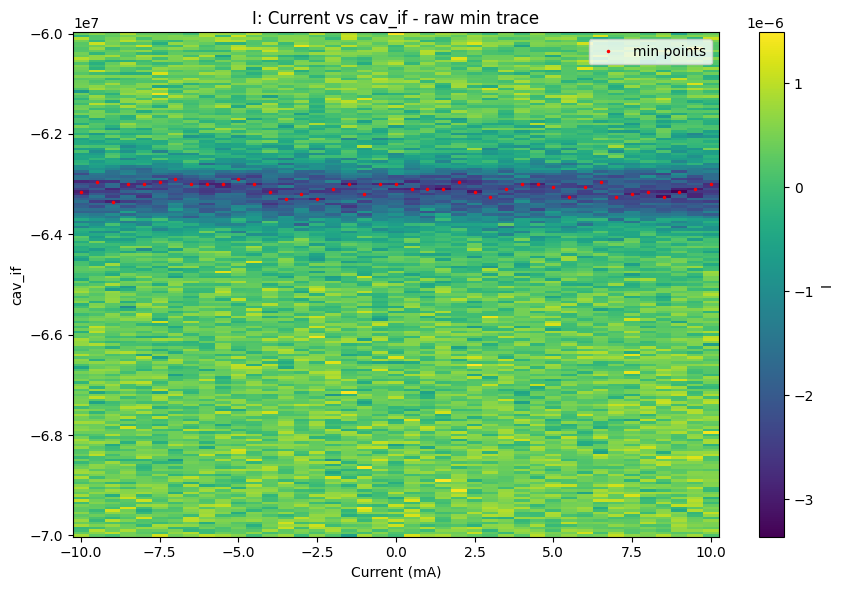

In [4]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# USER SETTINGS
# ==========================================================
build_npz_from_hdf5 = True
load_npz_for_analysis = True
current_A_print =np.linspace(start=-10e-3, stop=10e-3, num=41)
batches = [
    {
        "date": "2026-07-24",
        "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-08",
        "time": ((12, 48), (13, 2)),
        "current": current_A_print#[0:104]#np.linspace(-20e-3, 20e-3, 801)[0:237],
    },
    # {
    #     "date": "2026-07-05",
    #     "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-05",
    #     "time": ((0, 0), (6, 0)),
    #     "current": np.linspace(-20e-3, 20e-3, 801)[237:237+274],
    # },
]

file_key = "CavitySpec_versus_flux"
plot_data = "I"          # "I", "Q", or "MAG"
y_key = None             # None -> auto-choose sweep axis
subtract_mean = True
x_label, y_label = "Current", "cav_if"
show_individual_plots = False
plot_current_in_mA = True
output_folder = r"C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data"
os.makedirs(output_folder, exist_ok=True)

# Generate names dynamically
st_d, end_d = batches[0]["date"].replace("-", ""), batches[-1]["date"].replace("-", "")
st_h, st_m = batches[0]["time"][0]
end_h, end_m = batches[-1]["time"][1]
save_npz_name = f"{file_key}_{st_d}_{st_h:02d}{st_m:02d}_to_{end_d}_{end_h:02d}{end_m:02d}_{plot_data}.npz"
npz_path = os.path.join(output_folder, save_npz_name)

# Trace & Outlier Settings
find_mode = "min"        # "min" or "max"
current_min_mA, current_max_mA = -15, -8
remove_outliers = True
jump_threshold = 0.005   # 5 MHz if in GHz
save_min_trace = True

# ==========================================================
# HELPER FUNCTIONS
# ==========================================================

def extract_time(filename):
    try:
        parts = os.path.basename(filename).split("-")
        return (int(parts[0]), int(parts[1]))
    except Exception:
        return (-1, -1)

def get_filtered_files(folder, start_time, end_time, file_key):
    if not os.path.exists(folder):
        print(f"Folder not found: {folder}")
        return []
    files = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(".hdf5") and file_key in f]
    return sorted([f for f in files if start_time <= extract_time(f) <= end_time])

def load_one_hdf5(filename, y_key=None, subtract_mean=True):
    with h5py.File(filename, "r") as f:
        key = y_key or next(k for k in f.keys() if k not in {"I", "Q", "Magnitude"})
        y_vals = np.array(f[key][()])
        
        # Flatten array averages instantly
        I_val = np.mean(f["I"][()], axis=0) if f["I"].ndim > 1 else np.array(f["I"][()])
        Q_val = np.mean(f["Q"][()], axis=0) if f["Q"].ndim > 1 else np.array(f["Q"][()])
        mag_val = np.mean(f["Magnitude"][()], axis=0) if "Magnitude" in f.keys() else np.sqrt(I_val**2 + Q_val**2)

        if subtract_mean:
            I_val -= np.mean(I_val)
            Q_val -= np.mean(Q_val)
            mag_val -= np.mean(mag_val)
            
    return key, y_vals, I_val, Q_val, mag_val

def base_mesh_plot(x, y, z, title_suffix=""):
    """Consolidated 2D Mesh plotting template to remove duplicate code block."""
    plt.figure(figsize=(9, 6))
    x_plot = x * 1e3 if plot_current_in_mA else x
    plt.pcolormesh(x_plot, y, z.T, shading="auto", cmap="viridis")
    plt.xlabel(f"{x_label} ({'mA' if plot_current_in_mA else 'A'})")
    plt.ylabel(y_label)
    plt.title(f"{plot_data}: {x_label} vs {y_label} {title_suffix}")
    plt.colorbar(label=plot_data)
    plt.tight_layout()

# ==========================================================
# PROCESSING & ANALYSIS
# ==========================================================

if build_npz_from_hdf5:
    grouped_files, x_values, file_dates, file_times = [], [], [], []
    
    for b in batches:
        files = get_filtered_files(b["folder"], b["time"][0], b["time"][1], file_key)
        n = min(len(files), len(b["current"]))
        
        grouped_files.extend(files[:n])
        x_values.extend(b["current"][:n])
        file_dates.extend([b["date"]] * n)
        file_times.extend([extract_time(f) for f in files[:n]])

    if not grouped_files:
        raise ValueError("No matching HDF5 files found.")

    I_2d, Q_2d, MAG_2d, sweep_axis = [], [], [], []
    for i, fname in enumerate(grouped_files):
        key, y_vals, I_v, Q_v, M_v = load_one_hdf5(fname, y_key, subtract_mean)
        sweep_axis.append(y_vals)
        I_2d.append(I_v)
        Q_2d.append(Q_v)
        MAG_2d.append(M_v)

    y_values = sweep_axis[0]
    
    np.savez_compressed(
        npz_path, x_values=x_values, current=x_values, current_mA=np.array(x_values)*1e3,
        y_values=y_values, cav_if=y_values, sweep_axis=sweep_axis, I=I_2d, Q=Q_2d, MAG=MAG_2d,
        x_label=x_label, y_label=y_label, y_key=key, filenames=grouped_files, 
        file_dates=file_dates, file_times=file_times, batch_dates=[b["date"] for b in batches],
        batch_start_times=[b["time"][0] for b in batches], batch_end_times=[b["time"][1] for b in batches],
        batch_folders=[b["folder"] for b in batches], file_key=file_key, subtract_mean=subtract_mean, plot_data_saved=plot_data
    )
    print(f"Saved main NPZ to: {npz_path}")

if load_npz_for_analysis:
    data = np.load(npz_path, allow_pickle=True)
    x_values = data["current"]
    y_values = data["cav_if"] if "cav_if" in data.keys() else data["y_values"]
    data_2d = data[plot_data]

    # Step 3: Raw 2D Mesh Plot
    base_mesh_plot(x_values, y_values, data_2d)
    plt.show()

    # Step 4 & 5: Find Min/Max Trace & Plot Overlay
    idx = np.argmin(data_2d, axis=1) if find_mode == "min" else np.argmax(data_2d, axis=1)
    trace_y, trace_val = y_values[idx], data_2d[np.arange(data_2d.shape[0]), idx]

    base_mesh_plot(x_values, y_values, data_2d, f"- raw {find_mode} trace")
    plt.plot(x_values * 1e3 if plot_current_in_mA else x_values, trace_y, "r.", markersize=3, label=f"{find_mode} points")
    plt.legend()
    plt.show()

#     # Step 6: Filter Range
#     mask = (x_values * 1e3 >= current_min_mA) & (x_values * 1e3 <= current_max_mA)
#     x_sel, y_sel, val_sel = x_values[mask], trace_y[mask], trace_val[mask]

#     # Step 7: Clean Vectorized Outliers (No loop needed!)
#     good_mask = np.ones_like(y_sel, dtype=bool)
#     if remove_outliers and len(y_sel) > 2:
#         jump_left = np.abs(y_sel[1:-1] - y_sel[:-2])
#         jump_right = np.abs(y_sel[1:-1] - y_sel[2:])
#         good_mask[1:-1] = ~((jump_left > jump_threshold) & (jump_right > jump_threshold))

#     x_clean, cav_if_clean, value_clean = x_sel[good_mask], y_sel[good_mask], val_sel[good_mask]

#     # Step 8: Plot Profile Verification
#     plt.figure(figsize=(8, 4))
#     plt.plot(x_sel * 1e3, y_sel, "o", markersize=3, alpha=0.4, label="Selected raw points")
#     plt.plot(x_clean * 1e3, cav_if_clean, "o-", markersize=4, label="Cleaned points")
#     plt.grid(True); plt.legend(); plt.xlabel("Current (mA)"); plt.ylabel("cav_if")
#     plt.title(f"Cleaned {find_mode} trace, {plot_data}")
#     plt.tight_layout()
#     plt.show()

#     # Step 9: Cleaned 2D Focus Plot
#     base_mesh_plot(x_values, y_values, data_2d, f"- cleaned {find_mode} trace")
#     plt.plot(x_clean * 1e3, cav_if_clean, "r.-", markersize=4, label="Cleaned trace")
#     plt.xlim(current_min_mA, current_max_mA)
#     plt.legend()
#     plt.show()

#     # Step 10: Save Cleaned Data
#     if save_min_trace:
#         save_min_name = save_npz_name.replace(".npz", f"_{find_mode}_trace_{current_min_mA:g}_to_{current_max_mA:g}mA_cleaned.npz")
#         np.savez_compressed(
#             os.path.join(output_folder, save_min_name),
#             current=x_clean, current_mA=x_clean*1e3, cav_if=cav_if_clean, value=value_clean,
#             good_mask=good_mask, range_mask=mask, plot_data=plot_data, find_mode=find_mode
#         )

#     # Step 11: Final Printout
#     print(f"\ncurrent = [{', '.join(f'{x*1e3:.9g}' for x in x_clean)}]")
#     print(f"\ncav_if = [{', '.join(f'{y:.9g}' for y in cav_if_clean)}]")

Saved main NPZ to: C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data\SnailSpec_twotone_sideq_versus_flux_20260724_1455_to_20260724_1601_I.npz


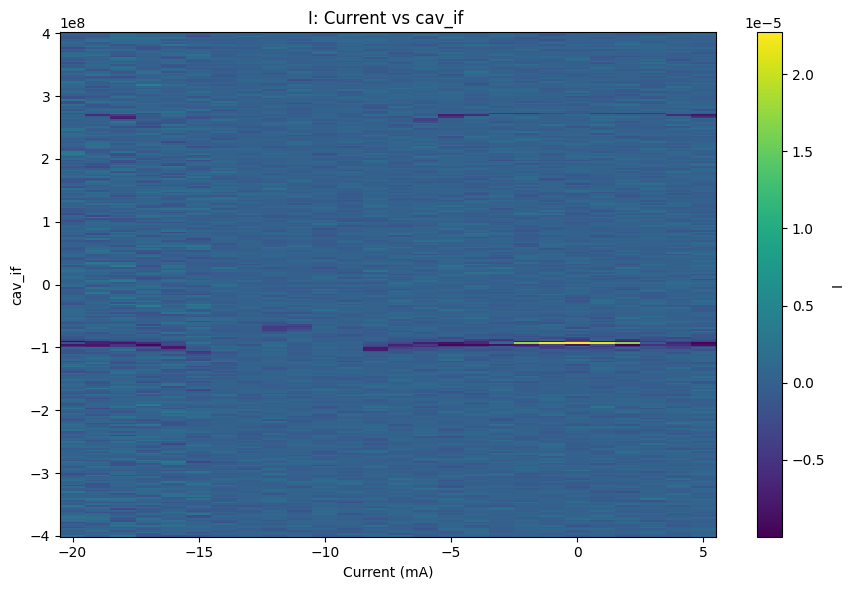

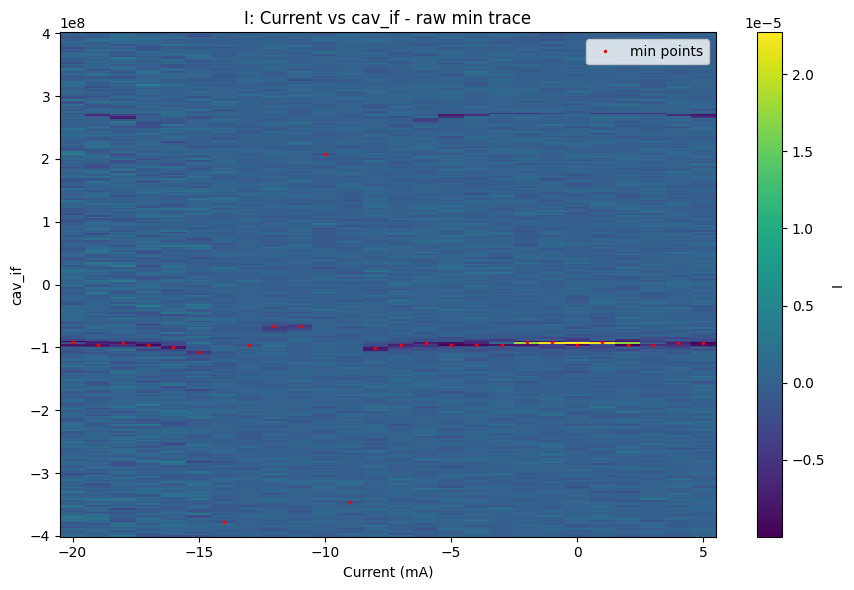

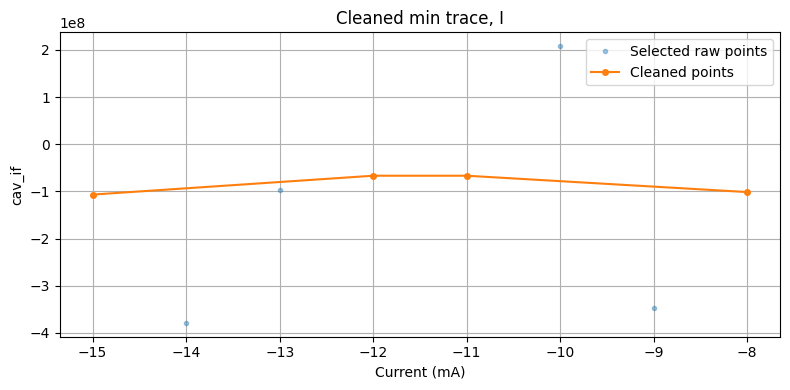

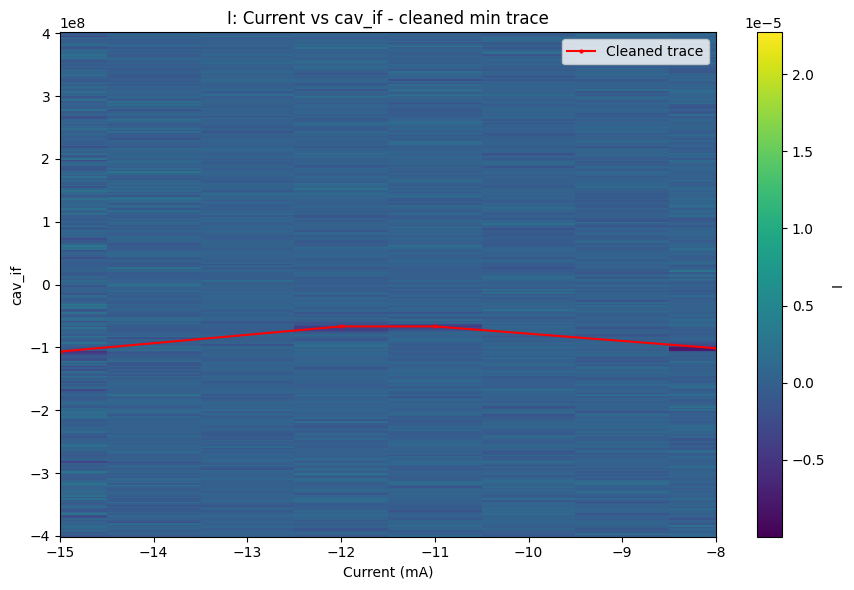


current = [-15, -12, -11, -8]

cav_if = [-106666740, -66666750, -66666750, -101333408]


In [5]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# USER SETTINGS
# ==========================================================
build_npz_from_hdf5 = True
load_npz_for_analysis = True
current_A_print =np.linspace(start=-20e-3, stop=5e-3, num=26)
batches = [
    {
        "date": "2026-07-24",
        "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-24",
        "time": ((14, 55), (16, 1)),
        "current": current_A_print#[0:104]#np.linspace(-20e-3, 20e-3, 801)[0:237],
    },
    # {
    #     "date": "2026-07-05",
    #     "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-05",
    #     "time": ((0, 0), (6, 0)),
    #     "current": np.linspace(-20e-3, 20e-3, 801)[237:237+274],
    # },
]

file_key = "SnailSpec_twotone_sideq_versus_flux"
plot_data = "I"          # "I", "Q", or "MAG"
y_key = None             # None -> auto-choose sweep axis
subtract_mean = True
x_label, y_label = "Current", "cav_if"
show_individual_plots = False
plot_current_in_mA = True
output_folder = r"C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data"
os.makedirs(output_folder, exist_ok=True)

# Generate names dynamically
st_d, end_d = batches[0]["date"].replace("-", ""), batches[-1]["date"].replace("-", "")
st_h, st_m = batches[0]["time"][0]
end_h, end_m = batches[-1]["time"][1]
save_npz_name = f"{file_key}_{st_d}_{st_h:02d}{st_m:02d}_to_{end_d}_{end_h:02d}{end_m:02d}_{plot_data}.npz"
npz_path = os.path.join(output_folder, save_npz_name)

# Trace & Outlier Settings
find_mode = "min"        # "min" or "max"
current_min_mA, current_max_mA = -15, -8
remove_outliers = True
jump_threshold = 0.005   # 5 MHz if in GHz
save_min_trace = True

# ==========================================================
# HELPER FUNCTIONS
# ==========================================================

def extract_time(filename):
    try:
        parts = os.path.basename(filename).split("-")
        return (int(parts[0]), int(parts[1]))
    except Exception:
        return (-1, -1)

def get_filtered_files(folder, start_time, end_time, file_key):
    if not os.path.exists(folder):
        print(f"Folder not found: {folder}")
        return []
    files = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(".hdf5") and file_key in f]
    return sorted([f for f in files if start_time <= extract_time(f) <= end_time])

def load_one_hdf5(filename, y_key=None, subtract_mean=True):
    with h5py.File(filename, "r") as f:
        key = y_key or next(k for k in f.keys() if k not in {"I", "Q", "Magnitude"})
        y_vals = np.array(f[key][()])
        
        # Flatten array averages instantly
        I_val = np.mean(f["I"][()], axis=0) if f["I"].ndim > 1 else np.array(f["I"][()])
        Q_val = np.mean(f["Q"][()], axis=0) if f["Q"].ndim > 1 else np.array(f["Q"][()])
        mag_val = np.mean(f["Magnitude"][()], axis=0) if "Magnitude" in f.keys() else np.sqrt(I_val**2 + Q_val**2)

        if subtract_mean:
            I_val -= np.mean(I_val)
            Q_val -= np.mean(Q_val)
            mag_val -= np.mean(mag_val)
            
    return key, y_vals, I_val, Q_val, mag_val

def base_mesh_plot(x, y, z, title_suffix=""):
    """Consolidated 2D Mesh plotting template to remove duplicate code block."""
    plt.figure(figsize=(9, 6))
    x_plot = x * 1e3 if plot_current_in_mA else x
    plt.pcolormesh(x_plot, y, z.T, shading="auto", cmap="viridis")
    plt.xlabel(f"{x_label} ({'mA' if plot_current_in_mA else 'A'})")
    plt.ylabel(y_label)
    plt.title(f"{plot_data}: {x_label} vs {y_label} {title_suffix}")
    plt.colorbar(label=plot_data)
    plt.tight_layout()

# ==========================================================
# PROCESSING & ANALYSIS
# ==========================================================

if build_npz_from_hdf5:
    grouped_files, x_values, file_dates, file_times = [], [], [], []
    
    for b in batches:
        files = get_filtered_files(b["folder"], b["time"][0], b["time"][1], file_key)
        n = min(len(files), len(b["current"]))
        
        grouped_files.extend(files[:n])
        x_values.extend(b["current"][:n])
        file_dates.extend([b["date"]] * n)
        file_times.extend([extract_time(f) for f in files[:n]])

    if not grouped_files:
        raise ValueError("No matching HDF5 files found.")

    I_2d, Q_2d, MAG_2d, sweep_axis = [], [], [], []
    for i, fname in enumerate(grouped_files):
        key, y_vals, I_v, Q_v, M_v = load_one_hdf5(fname, y_key, subtract_mean)
        sweep_axis.append(y_vals)
        I_2d.append(I_v)
        Q_2d.append(Q_v)
        MAG_2d.append(M_v)

    y_values = sweep_axis[0]
    
    np.savez_compressed(
        npz_path, x_values=x_values, current=x_values, current_mA=np.array(x_values)*1e3,
        y_values=y_values, cav_if=y_values, sweep_axis=sweep_axis, I=I_2d, Q=Q_2d, MAG=MAG_2d,
        x_label=x_label, y_label=y_label, y_key=key, filenames=grouped_files, 
        file_dates=file_dates, file_times=file_times, batch_dates=[b["date"] for b in batches],
        batch_start_times=[b["time"][0] for b in batches], batch_end_times=[b["time"][1] for b in batches],
        batch_folders=[b["folder"] for b in batches], file_key=file_key, subtract_mean=subtract_mean, plot_data_saved=plot_data
    )
    print(f"Saved main NPZ to: {npz_path}")

if load_npz_for_analysis:
    data = np.load(npz_path, allow_pickle=True)
    x_values = data["current"]
    y_values = data["cav_if"] if "cav_if" in data.keys() else data["y_values"]
    data_2d = data[plot_data]

    # Step 3: Raw 2D Mesh Plot
    base_mesh_plot(x_values, y_values, data_2d)
    plt.show()

    # Step 4 & 5: Find Min/Max Trace & Plot Overlay
    idx = np.argmin(data_2d, axis=1) if find_mode == "min" else np.argmax(data_2d, axis=1)
    trace_y, trace_val = y_values[idx], data_2d[np.arange(data_2d.shape[0]), idx]

    base_mesh_plot(x_values, y_values, data_2d, f"- raw {find_mode} trace")
    plt.plot(x_values * 1e3 if plot_current_in_mA else x_values, trace_y, "r.", markersize=3, label=f"{find_mode} points")
    plt.legend()
    plt.show()

    # Step 6: Filter Range
    mask = (x_values * 1e3 >= current_min_mA) & (x_values * 1e3 <= current_max_mA)
    x_sel, y_sel, val_sel = x_values[mask], trace_y[mask], trace_val[mask]

    # Step 7: Clean Vectorized Outliers (No loop needed!)
    good_mask = np.ones_like(y_sel, dtype=bool)
    if remove_outliers and len(y_sel) > 2:
        jump_left = np.abs(y_sel[1:-1] - y_sel[:-2])
        jump_right = np.abs(y_sel[1:-1] - y_sel[2:])
        good_mask[1:-1] = ~((jump_left > jump_threshold) & (jump_right > jump_threshold))

    x_clean, cav_if_clean, value_clean = x_sel[good_mask], y_sel[good_mask], val_sel[good_mask]

    # Step 8: Plot Profile Verification
    plt.figure(figsize=(8, 4))
    plt.plot(x_sel * 1e3, y_sel, "o", markersize=3, alpha=0.4, label="Selected raw points")
    plt.plot(x_clean * 1e3, cav_if_clean, "o-", markersize=4, label="Cleaned points")
    plt.grid(True); plt.legend(); plt.xlabel("Current (mA)"); plt.ylabel("cav_if")
    plt.title(f"Cleaned {find_mode} trace, {plot_data}")
    plt.tight_layout()
    plt.show()

    # Step 9: Cleaned 2D Focus Plot
    base_mesh_plot(x_values, y_values, data_2d, f"- cleaned {find_mode} trace")
    plt.plot(x_clean * 1e3, cav_if_clean, "r.-", markersize=4, label="Cleaned trace")
    plt.xlim(current_min_mA, current_max_mA)
    plt.legend()
    plt.show()

    # Step 10: Save Cleaned Data
    if save_min_trace:
        save_min_name = save_npz_name.replace(".npz", f"_{find_mode}_trace_{current_min_mA:g}_to_{current_max_mA:g}mA_cleaned.npz")
        np.savez_compressed(
            os.path.join(output_folder, save_min_name),
            current=x_clean, current_mA=x_clean*1e3, cav_if=cav_if_clean, value=value_clean,
            good_mask=good_mask, range_mask=mask, plot_data=plot_data, find_mode=find_mode
        )

    # Step 11: Final Printout
    print(f"\ncurrent = [{', '.join(f'{x*1e3:.9g}' for x in x_clean)}]")
    print(f"\ncav_if = [{', '.join(f'{y:.9g}' for y in cav_if_clean)}]")

Keys in NPZ:
['x_values', 'current', 'current_mA', 'y_values', 'cav_if', 'sweep_axis', 'I', 'Q', 'MAG', 'x_label', 'y_label', 'y_key', 'filenames', 'file_dates', 'file_times', 'batch_dates', 'batch_start_times', 'batch_end_times', 'batch_folders', 'file_key', 'subtract_mean', 'plot_data_saved']
x shape: (120,)
y shape: (101,)
z shape: (120, 101)


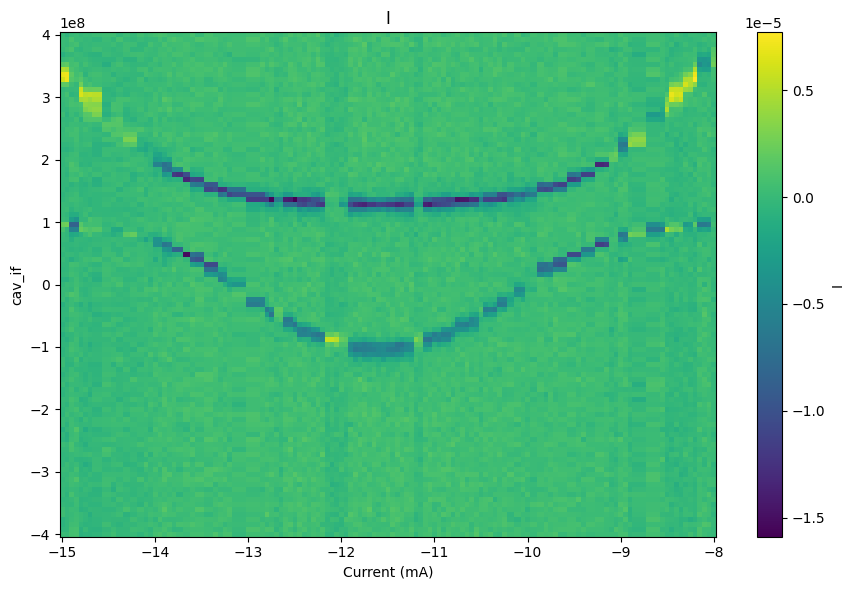

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# Load NPZ
# ==========================================================
npz_path = r"C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data\snail_spec_threetone_cavspec_versus_flux_20260705_1444_to_20260705_1743_I.npz"

data = np.load(npz_path, allow_pickle=True)

print("Keys in NPZ:")
print(data.files)

# ==========================================================
# Select data to plot
# ==========================================================
plot_data = "I"      # "I", "Q", or "MAG"

x = data["current"]          # Current (A)
y = data["cav_if"]           # Frequency axis

z = data[plot_data]

# Convert to numpy array in case it was saved as a list
z = np.asarray(z)

print("x shape:", x.shape)
print("y shape:", y.shape)
print("z shape:", z.shape)

# ==========================================================
# Plot
# ==========================================================
plt.figure(figsize=(9,6))

plt.pcolormesh(
    x * 1e3,        # convert to mA
    y,
    z.T,
    shading="auto",
    cmap="viridis"
)

plt.xlabel("Current (mA)")
plt.ylabel("cav_if")
plt.title(plot_data)
plt.colorbar(label=plot_data)

plt.tight_layout()
plt.show()

In [ ]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# USER SETTINGS
# ==========================================================
build_npz_from_hdf5 = True
load_npz_for_analysis = True

batches = [
    {
        "date": "2026-07-24",
        "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-24",
        "time": ((21, 16), (23, 59)),
        "current":  np.linspace(start=-33.3e6-12e6, stop=-33.3e6+12e6, num=481)[0:103],
    },
     {
        "date": "2026-07-25",
        "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-24",
        "time": ((0, 0), (11, 35)),
        "current":  np.linspace(start=-33.3e6-12e6, stop=-33.3e6+12e6, num=481)[103:],
    },

]

file_key = "CavitySWAP1D_len_loop"
plot_data = "MAG"          # "I", "Q", or "MAG"
y_key = None             # None -> auto-choose sweep axis
subtract_mean = True
x_label, y_label = "IF", "LEN"
show_individual_plots = False
plot_current_in_mA = True
output_folder = r"C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data"
os.makedirs(output_folder, exist_ok=True)

# Generate names dynamically
st_d, end_d = batches[0]["date"].replace("-", ""), batches[-1]["date"].replace("-", "")
st_h, st_m = batches[0]["time"][0]
end_h, end_m = batches[-1]["time"][1]
save_npz_name = f"{file_key}_{st_d}_{st_h:02d}{st_m:02d}_to_{end_d}_{end_h:02d}{end_m:02d}_{plot_data}.npz"
npz_path = os.path.join(output_folder, save_npz_name)

# Trace & Outlier Settings
find_mode = "min"        # "min" or "max"
current_min_mA, current_max_mA =-20, 5.5
remove_outliers = True
jump_threshold = 0.005   # 5 MHz if in GHz
save_min_trace = True

# ==========================================================
# HELPER FUNCTIONS
# ==========================================================

def extract_time(filename):
    try:
        parts = os.path.basename(filename).split("-")
        return (int(parts[0]), int(parts[1]))
    except Exception:
        return (-1, -1)

def get_filtered_files(folder, start_time, end_time, file_key):
    if not os.path.exists(folder):
        print(f"Folder not found: {folder}")
        return []
    files = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(".hdf5") and file_key in f]
    return sorted([f for f in files if start_time <= extract_time(f) <= end_time])

def load_one_hdf5(filename, y_key=None, subtract_mean=True):
    with h5py.File(filename, "r") as f:
        key = y_key or next(k for k in f.keys() if k not in {"I", "Q", "Magnitude"})
        y_vals = np.array(f[key][()])
        
        # Flatten array averages instantly
        I_val = np.mean(f["I"][()], axis=0) if f["I"].ndim > 1 else np.array(f["I"][()])
        Q_val = np.mean(f["Q"][()], axis=0) if f["Q"].ndim > 1 else np.array(f["Q"][()])
        mag_val = np.mean(f["Magnitude"][()], axis=0) if "Magnitude" in f.keys() else np.sqrt(I_val**2 + Q_val**2)

        if subtract_mean:
            I_val -= np.mean(I_val)
            Q_val -= np.mean(Q_val)
            mag_val -= np.mean(mag_val)
            
    return key, y_vals, I_val, Q_val, mag_val

def base_mesh_plot(x, y, z, title_suffix=""):
    """Consolidated 2D Mesh plotting template to remove duplicate code block."""
    plt.figure(figsize=(9, 6))
    x_plot = x * 1e3 if plot_current_in_mA else x
    plt.pcolormesh(x_plot, y, z.T, shading="auto", cmap="viridis")
    plt.xlabel(f"{x_label} ({'mA' if plot_current_in_mA else 'A'})")
    plt.ylabel(y_label)
    plt.title(f"{plot_data}: {x_label} vs {y_label} {title_suffix}")
    plt.colorbar(label=plot_data)
    plt.tight_layout()

# ==========================================================
# PROCESSING & ANALYSIS
# ==========================================================

if build_npz_from_hdf5:
    grouped_files, x_values, file_dates, file_times = [], [], [], []
    
    for b in batches:
        files = get_filtered_files(b["folder"], b["time"][0], b["time"][1], file_key)
        n = min(len(files), len(b["current"]))
        
        grouped_files.extend(files[:n])
        x_values.extend(b["current"][:n])
        file_dates.extend([b["date"]] * n)
        file_times.extend([extract_time(f) for f in files[:n]])

    if not grouped_files:
        raise ValueError("No matching HDF5 files found.")

    I_2d, Q_2d, MAG_2d, sweep_axis = [], [], [], []
    for i, fname in enumerate(grouped_files):
        key, y_vals, I_v, Q_v, M_v = load_one_hdf5(fname, y_key, subtract_mean)
        sweep_axis.append(y_vals)
        I_2d.append(I_v)
        Q_2d.append(Q_v)
        MAG_2d.append(M_v)

    y_values = sweep_axis[0]
    
    np.savez_compressed(
        npz_path, x_values=x_values, current=x_values, current_mA=np.array(x_values)*1e3,
        y_values=y_values, cav_if=y_values, sweep_axis=sweep_axis, I=I_2d, Q=Q_2d, MAG=MAG_2d,
        x_label=x_label, y_label=y_label, y_key=key, filenames=grouped_files, 
        file_dates=file_dates, file_times=file_times, batch_dates=[b["date"] for b in batches],
        batch_start_times=[b["time"][0] for b in batches], batch_end_times=[b["time"][1] for b in batches],
        batch_folders=[b["folder"] for b in batches], file_key=file_key, subtract_mean=subtract_mean, plot_data_saved=plot_data
    )
    print(f"Saved main NPZ to: {npz_path}")

if load_npz_for_analysis:
    data = np.load(npz_path, allow_pickle=True)
    x_values = data["current"]
    y_values = data["cav_if"] if "cav_if" in data.keys() else data["y_values"]
    data_2d = data[plot_data]

    # Step 3: Raw 2D Mesh Plot
    base_mesh_plot(x_values, y_values, data_2d)
    plt.show()

    # Step 4 & 5: Find Min/Max Trace & Plot Overlay
    idx = np.argmin(data_2d, axis=1) if find_mode == "min" else np.argmax(data_2d, axis=1)
    trace_y, trace_val = y_values[idx], data_2d[np.arange(data_2d.shape[0]), idx]

    base_mesh_plot(x_values, y_values, data_2d, f"- raw {find_mode} trace")
    plt.plot(x_values * 1e3 if plot_current_in_mA else x_values, trace_y, "r.", markersize=3, label=f"{find_mode} points")
    plt.legend()
    plt.show()

    # Step 6: Filter Range
    mask = (x_values * 1e3 >= current_min_mA) & (x_values * 1e3 <= current_max_mA)
    x_sel, y_sel, val_sel = x_values[mask], trace_y[mask], trace_val[mask]

    # Step 7: Clean Vectorized Outliers (No loop needed!)
    good_mask = np.ones_like(y_sel, dtype=bool)
    if remove_outliers and len(y_sel) > 2:
        jump_left = np.abs(y_sel[1:-1] - y_sel[:-2])
        jump_right = np.abs(y_sel[1:-1] - y_sel[2:])
        good_mask[1:-1] = ~((jump_left > jump_threshold) & (jump_right > jump_threshold))

    x_clean, cav_if_clean, value_clean = x_sel[good_mask], y_sel[good_mask], val_sel[good_mask]

    # Step 8: Plot Profile Verification
    plt.figure(figsize=(8, 4))
    plt.plot(x_sel * 1e3, y_sel, "o", markersize=3, alpha=0.4, label="Selected raw points")
    plt.plot(x_clean * 1e3, cav_if_clean, "o-", markersize=4, label="Cleaned points")
    plt.grid(True); plt.legend(); plt.xlabel("Current (mA)"); plt.ylabel("cav_if")
    plt.title(f"Cleaned {find_mode} trace, {plot_data}")
    plt.tight_layout()
    plt.show()

    # Step 9: Cleaned 2D Focus Plot
    base_mesh_plot(x_values, y_values, data_2d, f"- cleaned {find_mode} trace")
    plt.plot(x_clean * 1e3, cav_if_clean, "r.-", markersize=4, label="Cleaned trace")
    plt.xlim(current_min_mA, current_max_mA)
    plt.legend()
    plt.show()

    # Step 10: Save Cleaned Data
    if save_min_trace:
        save_min_name = save_npz_name.replace(".npz", f"_{find_mode}_trace_{current_min_mA:g}_to_{current_max_mA:g}mA_cleaned.npz")
        np.savez_compressed(
            os.path.join(output_folder, save_min_name),
            current=x_clean, current_mA=x_clean*1e3, cav_if=cav_if_clean, value=value_clean,
            good_mask=good_mask, range_mask=mask, plot_data=plot_data, find_mode=find_mode
        )

    # Step 11: Final Printout
    print(f"\ncurrent = [{', '.join(f'{x:.9g}' for x in x_clean)}]")
    print(f"\ncav_if = [{', '.join(f'{y:.9g}' for y in cav_if_clean)}]")

Saved main NPZ to: C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data\CavitySWAP1D_len_loop_20260724_2116_to_20260725_1135_phase.npz


KeyError: 'phase is not a file in the archive'

Saved main NPZ to: C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data\CavitySpec_versus_flux_20260703_1810_to_20260704_1400_I.npz


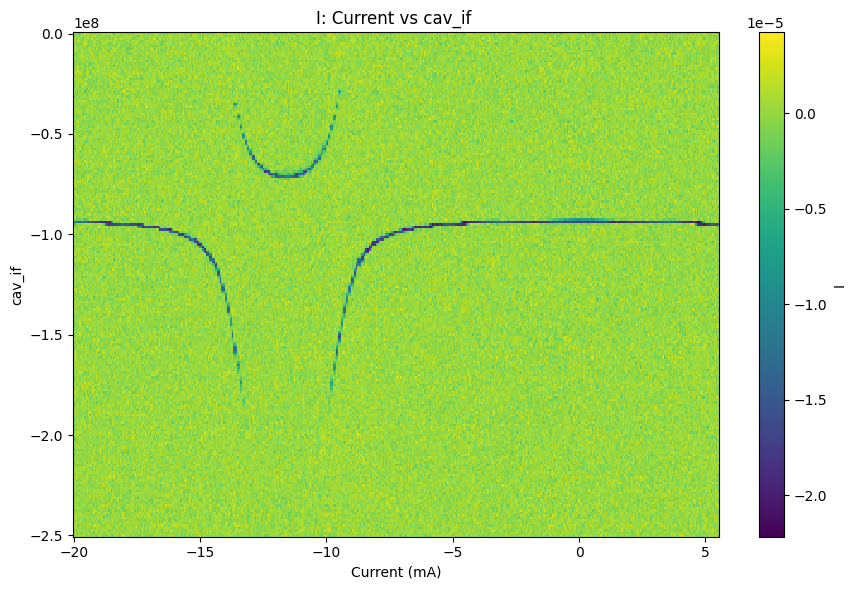

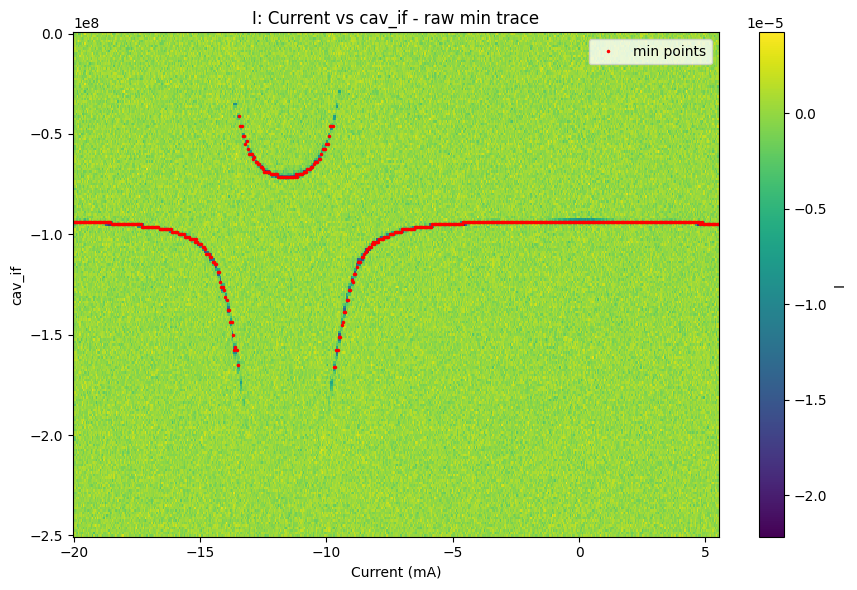

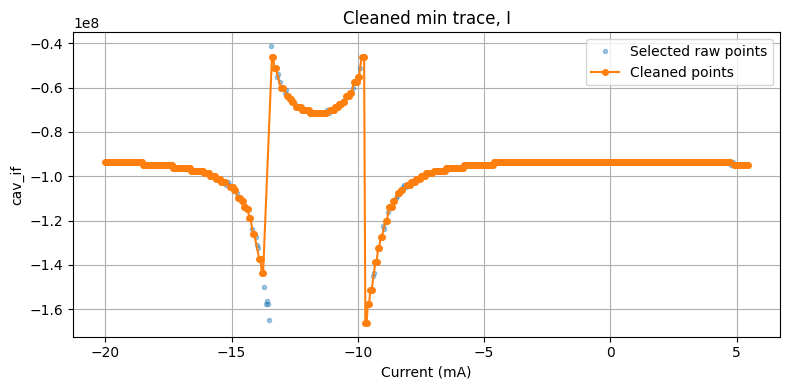

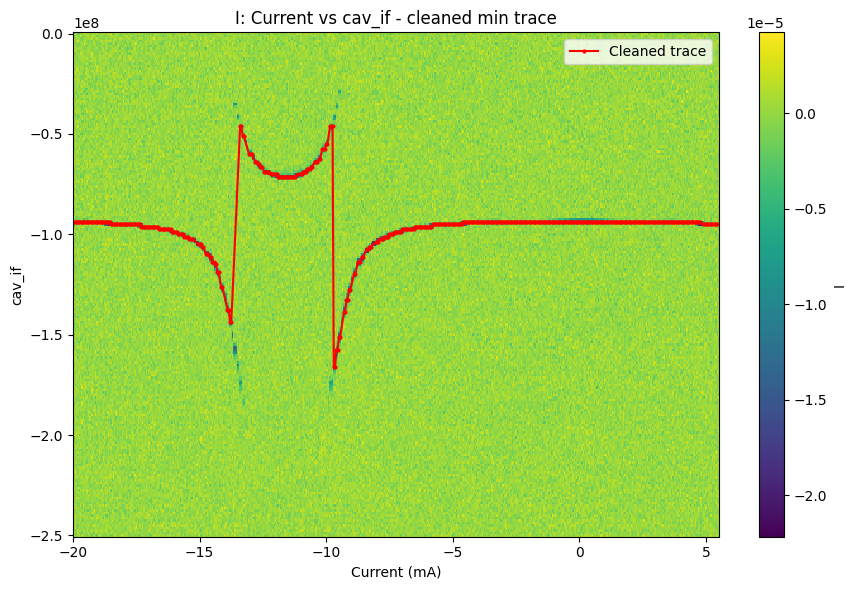


current = [-0.02, -0.01995, -0.0199, -0.01985, -0.0198, -0.01975, -0.0197, -0.01965, -0.0196, -0.01955, -0.0195, -0.01945, -0.0194, -0.01935, -0.0193, -0.01925, -0.0192, -0.01915, -0.0191, -0.01905, -0.019, -0.01895, -0.0189, -0.01885, -0.0188, -0.01875, -0.0187, -0.01865, -0.0186, -0.01855, -0.0185, -0.01845, -0.0184, -0.01835, -0.0183, -0.01825, -0.0182, -0.01815, -0.0181, -0.01805, -0.018, -0.01795, -0.0179, -0.01785, -0.0178, -0.01775, -0.0177, -0.01765, -0.0176, -0.01755, -0.0175, -0.01745, -0.0174, -0.01735, -0.0173, -0.01725, -0.0172, -0.01715, -0.0171, -0.01705, -0.017, -0.01695, -0.0169, -0.01685, -0.0168, -0.01675, -0.0167, -0.01665, -0.0166, -0.01655, -0.0165, -0.01645, -0.0164, -0.01635, -0.0163, -0.01625, -0.0162, -0.01615, -0.0161, -0.01605, -0.016, -0.01595, -0.0159, -0.01585, -0.0158, -0.01575, -0.0157, -0.01565, -0.0156, -0.01555, -0.0155, -0.01545, -0.0154, -0.01535, -0.0153, -0.01525, -0.01505, -0.015, -0.01495, -0.0149, -0.01485, -0.01475, -0.0147, -0.01465, -0.014

In [2]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# USER SETTINGS
# ==========================================================
build_npz_from_hdf5 = True
load_npz_for_analysis = True

batches = [
    {
        "date": "2026-07-03",
        "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-03",
        "time": ((18, 10), (23, 59)),
        "current": np.linspace(start=-20e-3, stop=20e-3, num=801)[0:248],
    },
    {
        "date": "2026-07-04",
        "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-04",
        "time": ((0, 0), (14, 0)),
        "current": np.linspace(start=-20e-3, stop=20e-3, num=801)[248:248+263],
    },
]

file_key = "CavitySpec_versus_flux"
plot_data = "I"          # "I", "Q", or "MAG"
y_key = None             # None -> auto-choose sweep axis
subtract_mean = True
x_label, y_label = "Current", "cav_if"
show_individual_plots = False
plot_current_in_mA = True
output_folder = r"C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data"
os.makedirs(output_folder, exist_ok=True)

# Generate names dynamically
st_d, end_d = batches[0]["date"].replace("-", ""), batches[-1]["date"].replace("-", "")
st_h, st_m = batches[0]["time"][0]
end_h, end_m = batches[-1]["time"][1]
save_npz_name = f"{file_key}_{st_d}_{st_h:02d}{st_m:02d}_to_{end_d}_{end_h:02d}{end_m:02d}_{plot_data}.npz"
npz_path = os.path.join(output_folder, save_npz_name)

# Trace & Outlier Settings
find_mode = "min"        # "min" or "max"
current_min_mA, current_max_mA =-20, 5.5
remove_outliers = True
jump_threshold = 0.005   # 5 MHz if in GHz
save_min_trace = True

# ==========================================================
# HELPER FUNCTIONS
# ==========================================================

def extract_time(filename):
    try:
        parts = os.path.basename(filename).split("-")
        return (int(parts[0]), int(parts[1]))
    except Exception:
        return (-1, -1)

def get_filtered_files(folder, start_time, end_time, file_key):
    if not os.path.exists(folder):
        print(f"Folder not found: {folder}")
        return []
    files = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(".hdf5") and file_key in f]
    return sorted([f for f in files if start_time <= extract_time(f) <= end_time])

def load_one_hdf5(filename, y_key=None, subtract_mean=True):
    with h5py.File(filename, "r") as f:
        key = y_key or next(k for k in f.keys() if k not in {"I", "Q", "Magnitude"})
        y_vals = np.array(f[key][()])
        
        # Flatten array averages instantly
        I_val = np.mean(f["I"][()], axis=0) if f["I"].ndim > 1 else np.array(f["I"][()])
        Q_val = np.mean(f["Q"][()], axis=0) if f["Q"].ndim > 1 else np.array(f["Q"][()])
        mag_val = np.mean(f["Magnitude"][()], axis=0) if "Magnitude" in f.keys() else np.sqrt(I_val**2 + Q_val**2)

        if subtract_mean:
            I_val -= np.mean(I_val)
            Q_val -= np.mean(Q_val)
            mag_val -= np.mean(mag_val)
            
    return key, y_vals, I_val, Q_val, mag_val

def base_mesh_plot(x, y, z, title_suffix=""):
    """Consolidated 2D Mesh plotting template to remove duplicate code block."""
    plt.figure(figsize=(9, 6))
    x_plot = x * 1e3 if plot_current_in_mA else x
    plt.pcolormesh(x_plot, y, z.T, shading="auto", cmap="viridis")
    plt.xlabel(f"{x_label} ({'mA' if plot_current_in_mA else 'A'})")
    plt.ylabel(y_label)
    plt.title(f"{plot_data}: {x_label} vs {y_label} {title_suffix}")
    plt.colorbar(label=plot_data)
    plt.tight_layout()

# ==========================================================
# PROCESSING & ANALYSIS
# ==========================================================

if build_npz_from_hdf5:
    grouped_files, x_values, file_dates, file_times = [], [], [], []
    
    for b in batches:
        files = get_filtered_files(b["folder"], b["time"][0], b["time"][1], file_key)
        n = min(len(files), len(b["current"]))
        
        grouped_files.extend(files[:n])
        x_values.extend(b["current"][:n])
        file_dates.extend([b["date"]] * n)
        file_times.extend([extract_time(f) for f in files[:n]])

    if not grouped_files:
        raise ValueError("No matching HDF5 files found.")

    I_2d, Q_2d, MAG_2d, sweep_axis = [], [], [], []
    for i, fname in enumerate(grouped_files):
        key, y_vals, I_v, Q_v, M_v = load_one_hdf5(fname, y_key, subtract_mean)
        sweep_axis.append(y_vals)
        I_2d.append(I_v)
        Q_2d.append(Q_v)
        MAG_2d.append(M_v)

    y_values = sweep_axis[0]
    
    np.savez_compressed(
        npz_path, x_values=x_values, current=x_values, current_mA=np.array(x_values)*1e3,
        y_values=y_values, cav_if=y_values, sweep_axis=sweep_axis, I=I_2d, Q=Q_2d, MAG=MAG_2d,
        x_label=x_label, y_label=y_label, y_key=key, filenames=grouped_files, 
        file_dates=file_dates, file_times=file_times, batch_dates=[b["date"] for b in batches],
        batch_start_times=[b["time"][0] for b in batches], batch_end_times=[b["time"][1] for b in batches],
        batch_folders=[b["folder"] for b in batches], file_key=file_key, subtract_mean=subtract_mean, plot_data_saved=plot_data
    )
    print(f"Saved main NPZ to: {npz_path}")

if load_npz_for_analysis:
    data = np.load(npz_path, allow_pickle=True)
    x_values = data["current"]
    y_values = data["cav_if"] if "cav_if" in data.keys() else data["y_values"]
    data_2d = data[plot_data]

    # Step 3: Raw 2D Mesh Plot
    base_mesh_plot(x_values, y_values, data_2d)
    plt.show()

    # Step 4 & 5: Find Min/Max Trace & Plot Overlay
    idx = np.argmin(data_2d, axis=1) if find_mode == "min" else np.argmax(data_2d, axis=1)
    trace_y, trace_val = y_values[idx], data_2d[np.arange(data_2d.shape[0]), idx]

    base_mesh_plot(x_values, y_values, data_2d, f"- raw {find_mode} trace")
    plt.plot(x_values * 1e3 if plot_current_in_mA else x_values, trace_y, "r.", markersize=3, label=f"{find_mode} points")
    plt.legend()
    plt.show()

    # Step 6: Filter Range
    mask = (x_values * 1e3 >= current_min_mA) & (x_values * 1e3 <= current_max_mA)
    x_sel, y_sel, val_sel = x_values[mask], trace_y[mask], trace_val[mask]

    # Step 7: Clean Vectorized Outliers (No loop needed!)
    good_mask = np.ones_like(y_sel, dtype=bool)
    if remove_outliers and len(y_sel) > 2:
        jump_left = np.abs(y_sel[1:-1] - y_sel[:-2])
        jump_right = np.abs(y_sel[1:-1] - y_sel[2:])
        good_mask[1:-1] = ~((jump_left > jump_threshold) & (jump_right > jump_threshold))

    x_clean, cav_if_clean, value_clean = x_sel[good_mask], y_sel[good_mask], val_sel[good_mask]

    # Step 8: Plot Profile Verification
    plt.figure(figsize=(8, 4))
    plt.plot(x_sel * 1e3, y_sel, "o", markersize=3, alpha=0.4, label="Selected raw points")
    plt.plot(x_clean * 1e3, cav_if_clean, "o-", markersize=4, label="Cleaned points")
    plt.grid(True); plt.legend(); plt.xlabel("Current (mA)"); plt.ylabel("cav_if")
    plt.title(f"Cleaned {find_mode} trace, {plot_data}")
    plt.tight_layout()
    plt.show()

    # Step 9: Cleaned 2D Focus Plot
    base_mesh_plot(x_values, y_values, data_2d, f"- cleaned {find_mode} trace")
    plt.plot(x_clean * 1e3, cav_if_clean, "r.-", markersize=4, label="Cleaned trace")
    plt.xlim(current_min_mA, current_max_mA)
    plt.legend()
    plt.show()

    # Step 10: Save Cleaned Data
    if save_min_trace:
        save_min_name = save_npz_name.replace(".npz", f"_{find_mode}_trace_{current_min_mA:g}_to_{current_max_mA:g}mA_cleaned.npz")
        np.savez_compressed(
            os.path.join(output_folder, save_min_name),
            current=x_clean, current_mA=x_clean*1e3, cav_if=cav_if_clean, value=value_clean,
            good_mask=good_mask, range_mask=mask, plot_data=plot_data, find_mode=find_mode
        )

    # Step 11: Final Printout
    print(f"\ncurrent = [{', '.join(f'{x:.9g}' for x in x_clean)}]")
    print(f"\ncav_if = [{', '.join(f'{y:.9g}' for y in cav_if_clean)}]")

In [12]:
print(f"\ncurrent = [{', '.join(f'{x*1e3:.9g}' for x in x_clean)}]")
print(f"\ncav_if = [{', '.join(f'{y:.9g}' for y in cav_if_clean)}]")


current = [-20, -19.95, -19.9, -19.85, -19.8, -19.75, -19.7, -19.65, -19.6, -19.55, -19.5, -19.45, -19.4, -19.35, -19.3, -19.25, -19.2, -19.15, -19.1, -19.05, -19, -18.95, -18.9, -18.85, -18.8, -18.75, -18.7, -18.65, -18.6, -18.55, -18.5, -18.45, -18.4, -18.35, -18.3, -18.25, -18.2, -18.15, -18.1, -18.05, -18, -17.95, -17.9, -17.85, -17.8, -17.75, -17.7, -17.65, -17.6, -17.55, -17.5, -17.45, -17.4, -17.35, -17.3, -17.25, -17.2, -17.15, -17.1, -17.05, -17, -16.95, -16.9, -16.85, -16.8, -16.75, -16.7, -16.65, -16.6, -16.55, -16.5, -16.45, -16.4, -16.35, -16.3, -16.25, -16.2, -16.15, -16.1, -16.05, -16, -15.95, -15.9, -15.85, -15.8, -15.75, -15.7, -15.65, -15.6, -15.55, -15.5, -15.45, -15.4, -15.35, -15.3, -15.25, -15.05, -15, -14.95, -14.9, -14.85, -14.75, -14.7, -14.65, -14.6, -14.55, -14.5, -14.45, -14.4, -14.35, -14.3, -14.25, -14.15, -14.1, -13.9, -13.85, -13.8, -13.75, -13.4, -13.35, -13.3, -13.25, -13.05, -13, -12.95, -12.8, -12.75, -12.7, -12.65, -12.6, -12.55, -12.45, -12.4, -12

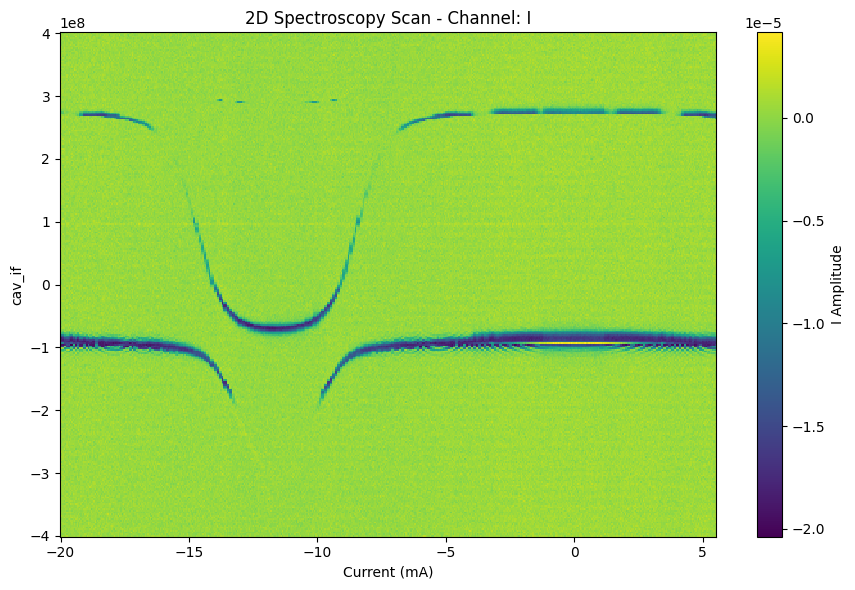

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# SELECTION CONFIGURATION
# ==========================================================
# Choose your channel here: "I", "Q", "MAG", or "PHASE"
CHOSEN_CHANNEL = "I"  

# Path to your master 2D dataset
file_path = r"C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data\SnailSpec_twotone_sideq_versus_flu_20260704_1906_to_20260705_0600_I.npz"

# ==========================================================
# LOAD AND COMPUTE
# ==========================================================
with np.load(file_path, allow_pickle=True) as data:
    current_mA = data["current_mA"]
    cav_if = data["cav_if"]
    
    I_matrix = data["I"]
    Q_matrix = data["Q"]

# Direct mapping dictionary using lazy computation
channel_map = {
    "I":     lambda: I_matrix,
    "Q":     lambda: Q_matrix,
    "MAG":   lambda: np.sqrt(I_matrix**2 + Q_matrix**2),
    "PHASE": lambda: np.arctan2(Q_matrix, I_matrix)  # Returns phase in radians (-π to π)
}

# Validate user choice safely
if CHOSEN_CHANNEL.upper() not in channel_map:
    raise ValueError(f"Invalid channel selection '{CHOSEN_CHANNEL}'. Choose from: {list(channel_map.keys())}")

# Extract selected matrix data
selected_matrix = channel_map[CHOSEN_CHANNEL.upper()]()

# Set up specific color map preferences (Phase looks much cleaner using a cyclic map like 'twilight')
cmap_choice = "twilight" if CHOSEN_CHANNEL.upper() == "PHASE" else "viridis"
cbar_label = "Phase (rad)" if CHOSEN_CHANNEL.upper() == "PHASE" else f"{CHOSEN_CHANNEL} Amplitude"

# ==========================================================
# GENERATE PLOT
# ==========================================================
plt.figure(figsize=(9, 6))

# .T transposes the data to align with current on X-axis and cav_if on Y-axis
plt.pcolormesh(current_mA, cav_if, selected_matrix.T, shading="auto", cmap=cmap_choice)

plt.xlabel("Current (mA)")
plt.ylabel("cav_if")
plt.title(f"2D Spectroscopy Scan - Channel: {CHOSEN_CHANNEL.upper()}")
plt.colorbar(label=cbar_label)

plt.tight_layout()
plt.show()

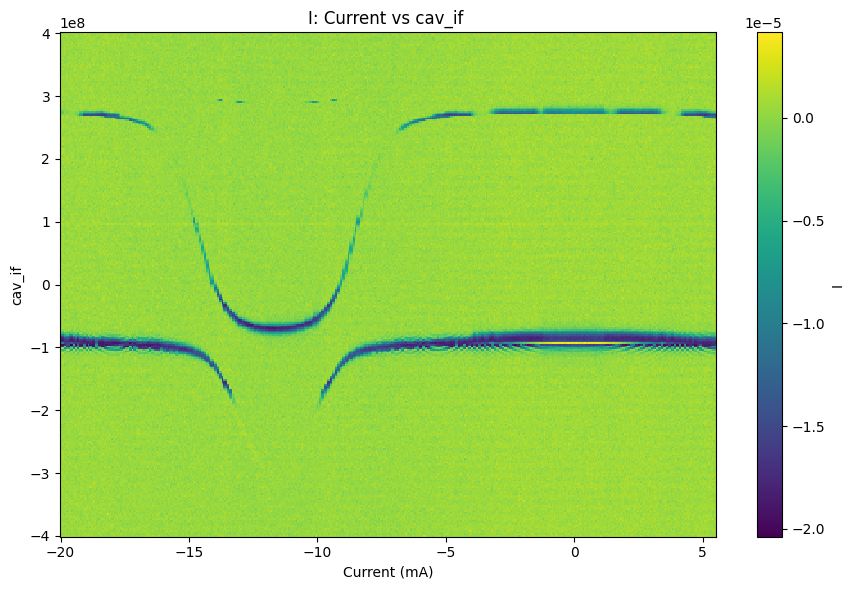

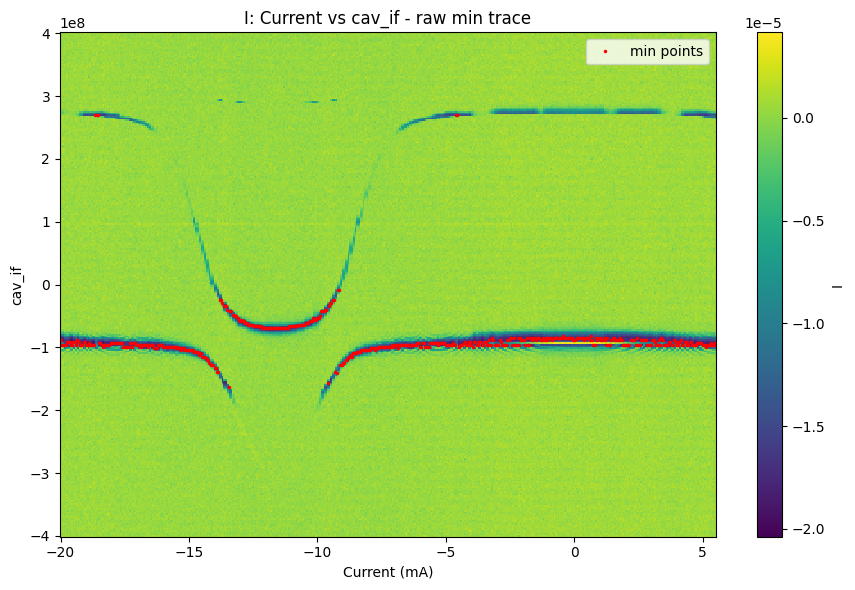

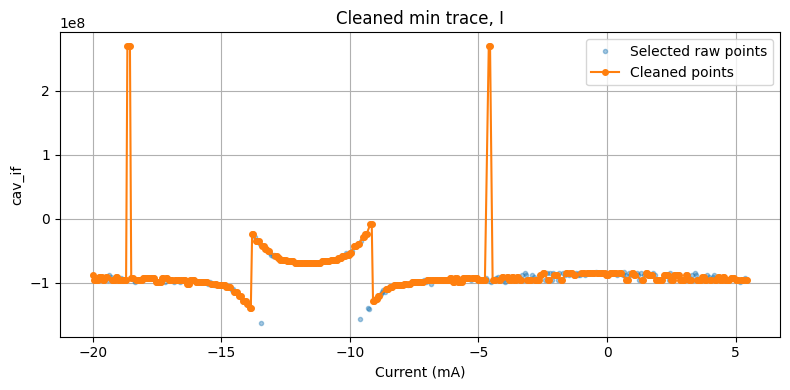

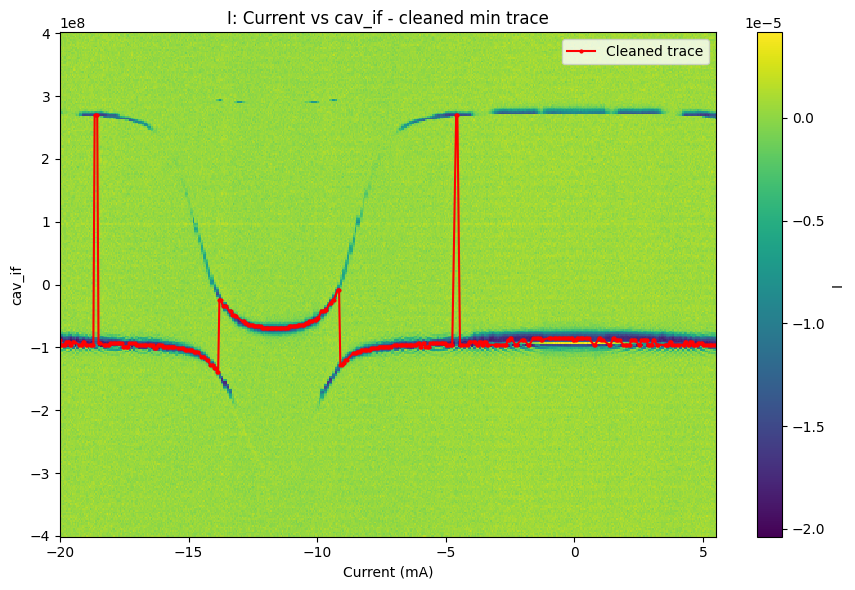


current = [-0.02, -0.01995, -0.0199, -0.01985, -0.0198, -0.01975, -0.0197, -0.01965, -0.0196, -0.01955, -0.0195, -0.01945, -0.01925, -0.0192, -0.01915, -0.0191, -0.01905, -0.019, -0.01895, -0.01885, -0.0188, -0.01875, -0.0187, -0.01865, -0.0186, -0.01855, -0.0185, -0.01845, -0.0183, -0.01825, -0.0182, -0.01815, -0.0181, -0.01805, -0.018, -0.01795, -0.0179, -0.01785, -0.0178, -0.01775, -0.0177, -0.01765, -0.0176, -0.01755, -0.0175, -0.01745, -0.0174, -0.01735, -0.0173, -0.01725, -0.01715, -0.0171, -0.01705, -0.017, -0.01695, -0.0169, -0.0168, -0.01675, -0.0167, -0.01665, -0.01655, -0.0165, -0.01645, -0.0164, -0.01635, -0.0163, -0.01625, -0.0162, -0.01615, -0.0161, -0.01605, -0.016, -0.01595, -0.0159, -0.01585, -0.0158, -0.01575, -0.0157, -0.01565, -0.0156, -0.01555, -0.0154, -0.01535, -0.01525, -0.0152, -0.01515, -0.0151, -0.01505, -0.015, -0.01495, -0.0149, -0.01485, -0.0148, -0.01475, -0.0147, -0.01465, -0.0145, -0.01445, -0.0144, -0.0143, -0.01425, -0.01415, -0.0141, -0.01405, -0.01

In [7]:
file_path = r"C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data\SnailSpec_twotone_sideq_versus_flu_20260704_1906_to_20260705_0600_I.npz"



data = np.load(file_path, allow_pickle=True)
x_values = data["current"]
y_values = data["cav_if"] if "cav_if" in data.keys() else data["y_values"]
data_2d = data[plot_data]

# Step 3: Raw 2D Mesh Plot
base_mesh_plot(x_values, y_values, data_2d)
plt.show()

# Step 4 & 5: Find Min/Max Trace & Plot Overlay
idx = np.argmin(data_2d, axis=1) if find_mode == "min" else np.argmax(data_2d, axis=1)
trace_y, trace_val = y_values[idx], data_2d[np.arange(data_2d.shape[0]), idx]

base_mesh_plot(x_values, y_values, data_2d, f"- raw {find_mode} trace")
plt.plot(x_values * 1e3 if plot_current_in_mA else x_values, trace_y, "r.", markersize=3, label=f"{find_mode} points")
plt.legend()
plt.show()

# Step 6: Filter Range
mask = (x_values * 1e3 >= current_min_mA) & (x_values * 1e3 <= current_max_mA)
x_sel, y_sel, val_sel = x_values[mask], trace_y[mask], trace_val[mask]

# Step 7: Clean Vectorized Outliers (No loop needed!)
good_mask = np.ones_like(y_sel, dtype=bool)
if remove_outliers and len(y_sel) > 2:
    jump_left = np.abs(y_sel[1:-1] - y_sel[:-2])
    jump_right = np.abs(y_sel[1:-1] - y_sel[2:])
    good_mask[1:-1] = ~((jump_left > jump_threshold) & (jump_right > jump_threshold))

x_clean, cav_if_clean, value_clean = x_sel[good_mask], y_sel[good_mask], val_sel[good_mask]

# Step 8: Plot Profile Verification
plt.figure(figsize=(8, 4))
plt.plot(x_sel * 1e3, y_sel, "o", markersize=3, alpha=0.4, label="Selected raw points")
plt.plot(x_clean * 1e3, cav_if_clean, "o-", markersize=4, label="Cleaned points")
plt.grid(True); plt.legend(); plt.xlabel("Current (mA)"); plt.ylabel("cav_if")
plt.title(f"Cleaned {find_mode} trace, {plot_data}")
plt.tight_layout()
plt.show()

# Step 9: Cleaned 2D Focus Plot
base_mesh_plot(x_values, y_values, data_2d, f"- cleaned {find_mode} trace")
plt.plot(x_clean * 1e3, cav_if_clean, "r.-", markersize=4, label="Cleaned trace")
plt.xlim(current_min_mA, current_max_mA)
plt.legend()
plt.show()

# Step 10: Save Cleaned Data
if save_min_trace:
    save_min_name = save_npz_name.replace(".npz", f"_{find_mode}_trace_{current_min_mA:g}_to_{current_max_mA:g}mA_cleaned.npz")
    np.savez_compressed(
        os.path.join(output_folder, save_min_name),
        current=x_clean, current_mA=x_clean*1e3, cav_if=cav_if_clean, value=value_clean,
        good_mask=good_mask, range_mask=mask, plot_data=plot_data, find_mode=find_mode
    )

# Step 11: Final Printout
print(f"\ncurrent = [{', '.join(f'{x:.9g}' for x in x_clean)}]")
# print(f"\ncav_if = [{', '.join(f'{y:.9g}' for y in cav_if_clean)}]")`

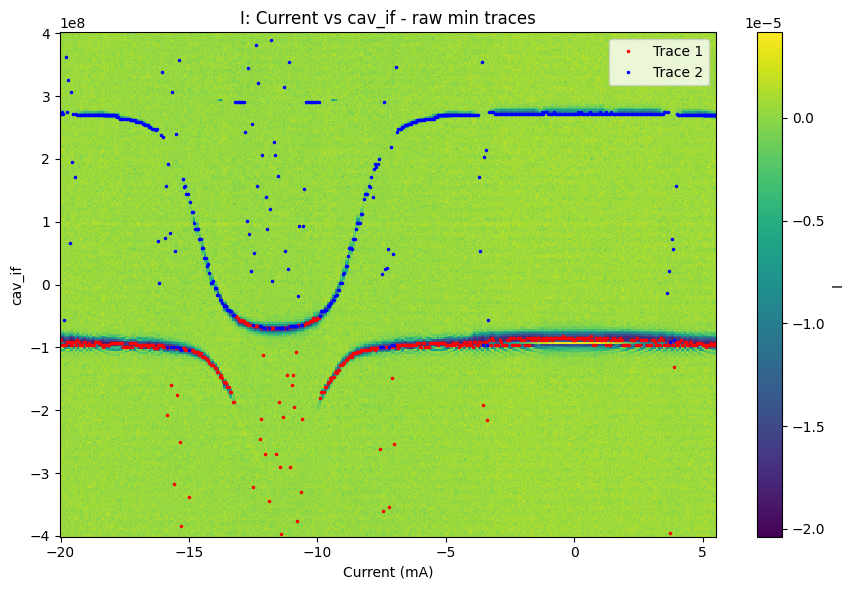

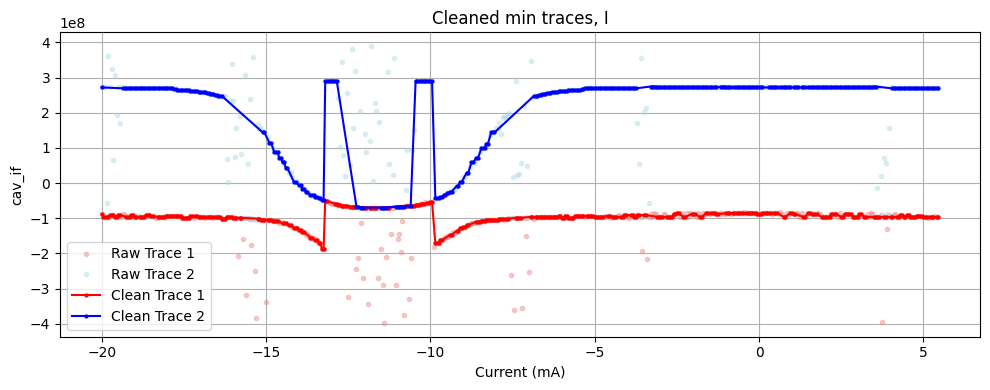

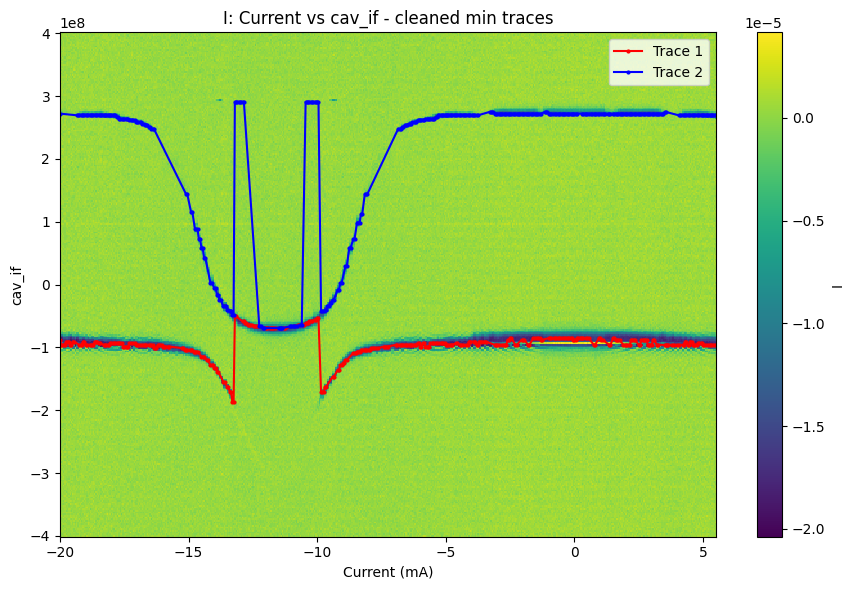

In [8]:
from scipy.signal import find_peaks
import os

# Step 4 & 5: Find TWO Min/Max Traces & Plot Overlay
idx1 = np.zeros(data_2d.shape[0], dtype=int)
idx2 = np.zeros(data_2d.shape[0], dtype=int)

# Minimum index separation between the two peaks to avoid picking two points in the exact same dip.
# You may need to tune this depending on the width of your resonances! (e.g., 5, 10, or len/20)
min_separation = max(1, len(y_values) // 20) 

for i in range(data_2d.shape[0]):
    row = data_2d[i, :]
    
    if find_mode == "min":
        # Find peaks on the inverted row to find dips
        peaks, _ = find_peaks(-row, distance=min_separation)
        # Sort found peaks by their actual minimum values (lowest first)
        sorted_peaks = peaks[np.argsort(row[peaks])]
    else:
        # Find peaks normally
        peaks, _ = find_peaks(row, distance=min_separation)
        # Sort found peaks by their actual maximum values (highest first)
        sorted_peaks = peaks[np.argsort(-row[peaks])]
        
    if len(sorted_peaks) >= 2:
        idx1[i], idx2[i] = sorted_peaks[0], sorted_peaks[1]
    elif len(sorted_peaks) == 1:
        idx1[i], idx2[i] = sorted_peaks[0], sorted_peaks[0] # Fallback if only 1 found
    else:
        # Absolute fallback if find_peaks fails entirely
        idx = np.argmin(row) if find_mode == "min" else np.argmax(row)
        idx1[i], idx2[i] = idx, idx

# Sort indices so trace 1 is always the lower frequency/value and trace 2 is the higher. 
# This prevents the two lines from randomly criss-crossing in your plots.
for i in range(data_2d.shape[0]):
    if idx1[i] > idx2[i]:
        idx1[i], idx2[i] = idx2[i], idx1[i]

trace1_y = y_values[idx1]
trace1_val = data_2d[np.arange(data_2d.shape[0]), idx1]

trace2_y = y_values[idx2]
trace2_val = data_2d[np.arange(data_2d.shape[0]), idx2]

# Plot Raw Traces
base_mesh_plot(x_values, y_values, data_2d, f"- raw {find_mode} traces")
plt.plot(x_values * 1e3 if plot_current_in_mA else x_values, trace1_y, "r.", markersize=3, label="Trace 1")
plt.plot(x_values * 1e3 if plot_current_in_mA else x_values, trace2_y, "b.", markersize=3, label="Trace 2")
plt.legend()
plt.show()

# Step 6: Filter Range
mask = (x_values * 1e3 >= current_min_mA) & (x_values * 1e3 <= current_max_mA)
x_sel = x_values[mask]
t1_y_sel, t1_val_sel = trace1_y[mask], trace1_val[mask]
t2_y_sel, t2_val_sel = trace2_y[mask], trace2_val[mask]

# Step 7: Clean Vectorized Outliers (Helper function for both traces)
def clean_trace_outliers(y_sel):
    good_mask = np.ones_like(y_sel, dtype=bool)
    if remove_outliers and len(y_sel) > 2:
        jump_left = np.abs(y_sel[1:-1] - y_sel[:-2])
        jump_right = np.abs(y_sel[1:-1] - y_sel[2:])
        good_mask[1:-1] = ~((jump_left > jump_threshold) & (jump_right > jump_threshold))
    return good_mask

mask1 = clean_trace_outliers(t1_y_sel)
mask2 = clean_trace_outliers(t2_y_sel)

x_clean1, y_clean1, val_clean1 = x_sel[mask1], t1_y_sel[mask1], t1_val_sel[mask1]
x_clean2, y_clean2, val_clean2 = x_sel[mask2], t2_y_sel[mask2], t2_val_sel[mask2]

# Step 8: Plot Profile Verification
plt.figure(figsize=(10, 4))
plt.plot(x_sel * 1e3, t1_y_sel, "o", color="lightcoral", markersize=3, alpha=0.4, label="Raw Trace 1")
plt.plot(x_sel * 1e3, t2_y_sel, "o", color="lightblue", markersize=3, alpha=0.4, label="Raw Trace 2")
plt.plot(x_clean1 * 1e3, y_clean1, "r.-", markersize=4, label="Clean Trace 1")
plt.plot(x_clean2 * 1e3, y_clean2, "b.-", markersize=4, label="Clean Trace 2")
plt.grid(True)
plt.legend()
plt.xlabel("Current (mA)")
plt.ylabel("cav_if")
plt.title(f"Cleaned {find_mode} traces, {plot_data}")
plt.tight_layout()
plt.show()

# Step 9: Cleaned 2D Focus Plot
base_mesh_plot(x_values, y_values, data_2d, f"- cleaned {find_mode} traces")
plt.plot(x_clean1 * 1e3, y_clean1, "r.-", markersize=4, label="Trace 1")
plt.plot(x_clean2 * 1e3, y_clean2, "b.-", markersize=4, label="Trace 2")
plt.xlim(current_min_mA, current_max_mA)
plt.legend()
plt.show()

# Step 10: Save Cleaned Data
if save_min_trace:
    save_min_name = save_npz_name.replace(".npz", f"_{find_mode}_traces_{current_min_mA:g}_to_{current_max_mA:g}mA_cleaned.npz")
    np.savez_compressed(
        os.path.join(output_folder, save_min_name),
        current_mA=x_sel*1e3, 
        
        # Saved separately because the outlier masks might remove different numbers of points for each trace
        x_clean1=x_clean1, cav_if_1=y_clean1, value_1=val_clean1,
        x_clean2=x_clean2, cav_if_2=y_clean2, value_2=val_clean2,
        
        plot_data=plot_data, find_mode=find_mode
    )

Keys in npz file: ['current_mA', 'x_clean1', 'cav_if_1', 'value_1', 'x_clean2', 'cav_if_2', 'value_2', 'plot_data', 'find_mode']


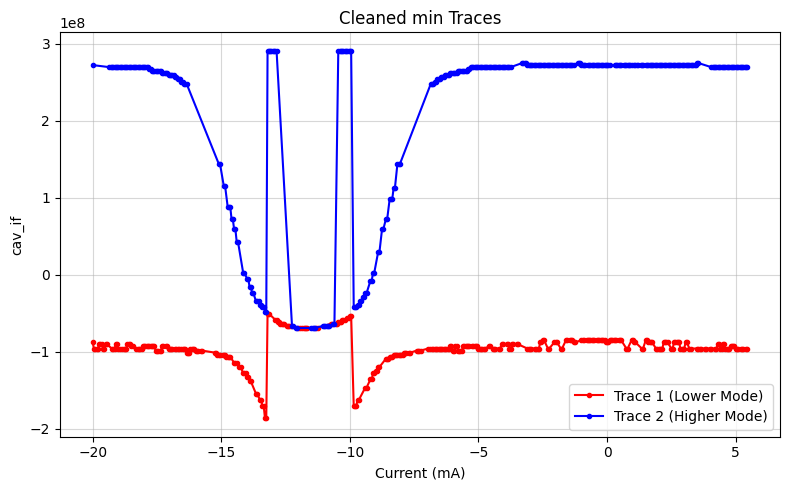

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Point this to the newly saved cleaned .npz file
# (Replace with your actual saved filename from Step 10)
filepath = r"C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data\CavitySpec_versus_flux_20260703_1810_to_20260704_1400_I_min_traces_-20_to_5.5mA_cleaned.npz"

# 2. Load the file
data = np.load(filepath, allow_pickle=True)

# (Optional) Print all keys in the file to see what's available
print("Keys in npz file:", data.files)

# 3. Extract Trace 1 (Lower frequency/cav_if mode)
# Convert x_clean1 from Amps to mA for plotting
x1_mA = data["x_clean1"] * 1e3  
y1 = data["cav_if_1"]

# 4. Extract Trace 2 (Higher frequency/cav_if mode)
x2_mA = data["x_clean2"] * 1e3
y2 = data["cav_if_2"]

# 5. Plot the traces
plt.figure(figsize=(8, 5))

plt.plot(x1_mA, y1, "r.-", markersize=6, label="Trace 1 (Lower Mode)")
plt.plot(x2_mA, y2, "b.-", markersize=6, label="Trace 2 (Higher Mode)")

plt.title(f"Cleaned {data['find_mode']} Traces")
plt.xlabel("Current (mA)")
plt.ylabel("cav_if")
plt.grid(True, alpha=0.5)
plt.legend()
plt.tight_layout()

plt.show()

Keys in NPZ:
['x_values', 'current', 'current_mA', 'y_values', 'cav_if', 'sweep_axis', 'I', 'Q', 'MAG', 'x_label', 'y_label', 'y_key', 'filenames', 'file_dates', 'file_times', 'batch_dates', 'batch_start_times', 'batch_end_times', 'batch_folders', 'file_key', 'subtract_mean', 'plot_data_saved']
x shape: (120,)
y shape: (101,)
z shape: (120, 101)


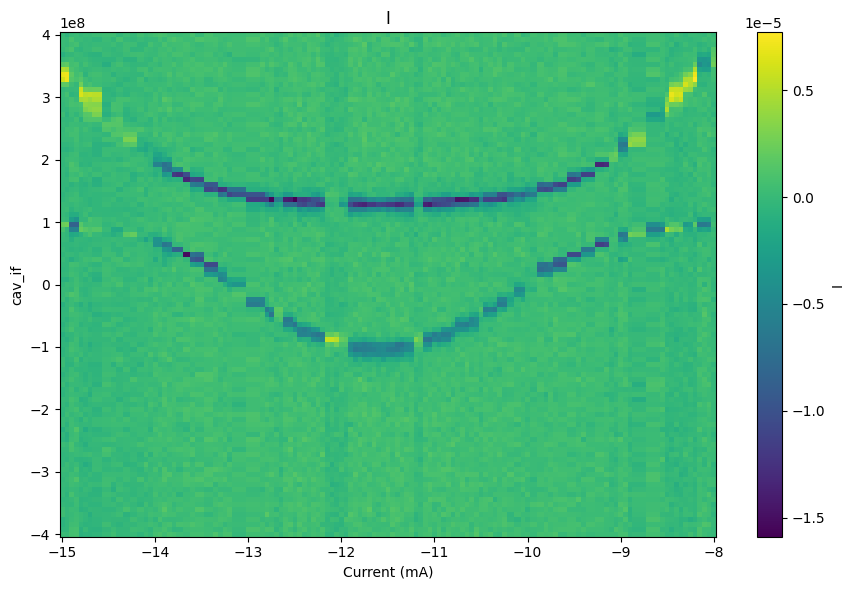

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# Load NPZ
# ==========================================================
npz_path = r"C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data\snail_spec_threetone_cavspec_versus_flux_20260705_1444_to_20260705_1743_I.npz"

data = np.load(npz_path, allow_pickle=True)

print("Keys in NPZ:")
print(data.files)

# ==========================================================
# Select data to plot
# ==========================================================
plot_data = "I"      # "I", "Q", or "MAG"

x = data["current"]          # Current (A)
y = data["cav_if"]           # Frequency axis

z = data[plot_data]

# Convert to numpy array in case it was saved as a list
z = np.asarray(z)

print("x shape:", x.shape)
print("y shape:", y.shape)
print("z shape:", z.shape)

# ==========================================================
# Plot
# ==========================================================
plt.figure(figsize=(9,6))

plt.pcolormesh(
    x * 1e3,        # convert to mA
    y,
    z.T,
    shading="auto",
    cmap="viridis"
)

plt.xlabel("Current (mA)")
plt.ylabel("cav_if")
plt.title(plot_data)
plt.colorbar(label=plot_data)

plt.tight_layout()
plt.show()

Keys in NPZ:
['x_values', 'current', 'current_mA', 'y_values', 'cav_if', 'sweep_axis', 'I', 'Q', 'MAG', 'x_label', 'y_label', 'y_key', 'filenames', 'file_dates', 'file_times', 'batch_dates', 'batch_start_times', 'batch_end_times', 'batch_folders', 'file_key', 'subtract_mean', 'plot_data_saved']
x shape: (120,)
y shape: (101,)
z shape: (120, 101)


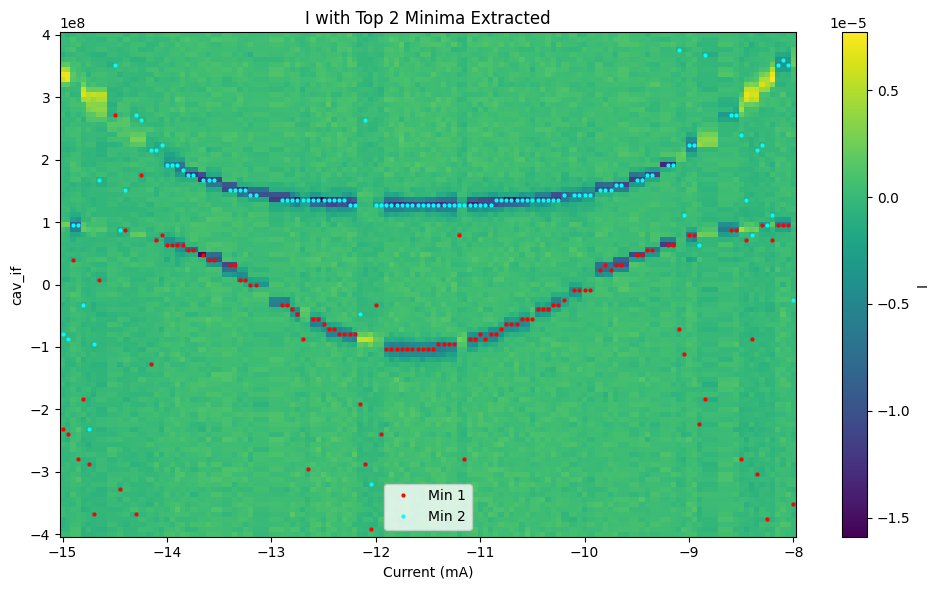

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# ==========================================================
# Load NPZ
# ==========================================================
npz_path = r"C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data\snail_spec_threetone_cavspec_versus_flux_20260705_1444_to_20260705_1743_I.npz"

data = np.load(npz_path, allow_pickle=True)

print("Keys in NPZ:")
print(data.files)

# ==========================================================
# Select data to plot
# ==========================================================
plot_data = "I"      # "I", "Q", or "MAG"

x = data["current"]          # Current (A)
y = data["cav_if"]           # Frequency axis
z = data[plot_data]

# Convert to numpy array in case it was saved as a list
z = np.asarray(z)

print("x shape:", x.shape)
print("y shape:", y.shape)
print("z shape:", z.shape)

# ==========================================================
# Extract Multiple Minima
# ==========================================================
num_minima = 2  # Change this to 3 or 4 if you expect more modes
min_separation = max(1, len(y) // 20) # Prevents picking two points in the same noise dip

# Create an array filled with NaNs to hold our y-values.
# Shape: (number_of_flux_points, num_minima)
extracted_minima = np.full((len(x), num_minima), np.nan)

for i in range(len(x)):
    row = z[i, :]
    
    # Find peaks on the inverted row to locate dips
    peaks, _ = find_peaks(-row, distance=min_separation)
    
    if len(peaks) > 0:
        # Sort found peaks by their actual Z values (lowest first)
        sorted_peaks = peaks[np.argsort(row[peaks])]
        
        # Take up to `num_minima`
        n_found = min(len(sorted_peaks), num_minima)
        
        # Get the actual y-values (frequencies) for these peak indices
        y_vals = y[sorted_peaks[:n_found]]
        
        # Sort the y-values so Trace 0 is always the lowest frequency, 
        # Trace 1 is the next highest, etc. (Stops colors from criss-crossing)
        extracted_minima[i, :n_found] = np.sort(y_vals)

# ==========================================================
# Plot Colormap + Overlaid Minima
# ==========================================================
plt.figure(figsize=(10, 6))

# 1. Base Colormap
plt.pcolormesh(
    x * 1e3,        # convert to mA
    y,
    z.T,
    shading="auto",
    cmap="viridis"
)

# 2. Overlay Traces
# List of colors for the traces (add more if num_minima > 4)
colors = ["red", "cyan", "magenta", "orange"] 

for m in range(num_minima):
    # We plot using '.' so that NaNs are ignored cleanly
    plt.plot(x * 1e3, extracted_minima[:, m], '.', 
             color=colors[m % len(colors)], 
             markersize=4, 
             label=f'Min {m+1}')

plt.xlabel("Current (mA)")
plt.ylabel("cav_if")
plt.title(f"{plot_data} with Top {num_minima} Minima Extracted")
plt.colorbar(label=plot_data)
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
# ==========================================================
# Save Extracted Minima to NPZ
# ==========================================================
import os

# Generate a new filename based on the original one
save_path = npz_path.replace(".npz", f"_extracted_{num_minima}_minima.npz")

# Save the arrays
np.savez_compressed(
    save_path,
    current=x,
    current_mA=x * 1e3,
    extracted_minima=extracted_minima,  # The 2D array of y-values we generated
    num_minima=num_minima,
    plot_data=plot_data
)

print(f"\nSuccessfully saved {num_minima} minima to:")
print(save_path)


Successfully saved 2 minima to:
C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data\snail_spec_threetone_cavspec_versus_flux_20260705_1444_to_20260705_1743_I_extracted_2_minima.npz


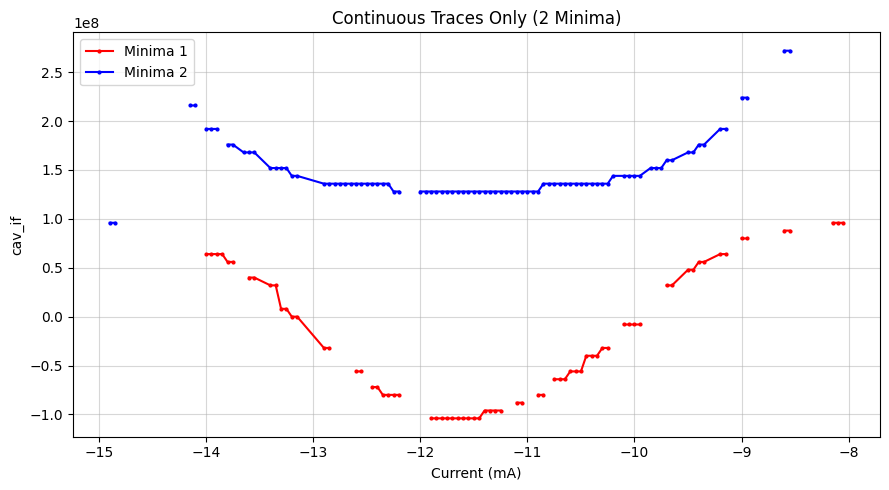

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Point to the file you just saved
file_path = r"C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data\snail_spec_threetone_cavspec_versus_flux_20260705_1444_to_20260705_1743_I_extracted_2_minima.npz"

data = np.load(file_path, allow_pickle=True)

x_mA = data["current_mA"]
minima_array = data["extracted_minima"]
num_minima = data["num_minima"]

# ==========================================================
# 2. CONTINUITY FILTER SETTINGS
# ==========================================================
# Maximum allowed jump between adjacent points. 
# -> If your cav_if is in GHz (e.g., 5.1), try 0.01 or 0.05
# -> If your cav_if is in Hz (e.g., 5e9), try 10e6 (10 MHz)
jump_threshold = 0.05  # <--- TUNE THIS VALUE

plt.figure(figsize=(9, 5))
colors = ["red", "blue", "green", "orange"]

for m in range(num_minima):
    # Copy the trace so we don't modify the loaded data
    trace_y = minima_array[:, m].copy()
    
    # Calculate the absolute jump to the left and right neighbor
    jump_left = np.full_like(trace_y, np.inf)
    jump_right = np.full_like(trace_y, np.inf)
    
    # Fill differences (ignoring NaNs warnings safely)
    with np.errstate(invalid='ignore'):
        jump_left[1:] = np.abs(trace_y[1:] - trace_y[:-1])
        jump_right[:-1] = np.abs(trace_y[1:] - trace_y[:-1])
        
        # A point is "continuous" if it is close to AT LEAST ONE of its neighbors
        is_continuous = (jump_left < jump_threshold) | (jump_right < jump_threshold)
    
    # Overwrite isolated/jumpy points with NaN
    trace_y[~is_continuous] = np.nan
    
    # Plot (Matplotlib naturally breaks the line where NaNs exist)
    plt.plot(x_mA, trace_y, '.-', markersize=4, color=colors[m % len(colors)], label=f'Minima {m+1}')

plt.title(f"Continuous Traces Only ({num_minima} Minima)")
plt.xlabel("Current (mA)")
plt.ylabel("cav_if")
plt.grid(True, alpha=0.5)
plt.legend()
plt.tight_layout()

plt.show()


Batch: C:/Users/qcrew/Desktop/Juncheng/victoria/data/2026-07-18
Found 134 files

Batch: C:/Users/qcrew/Desktop/Juncheng/victoria/data/2026-07-19
Found 377 files

Total files loaded: 511

Available keys:
  snail_EF_frequency
  I
  Q
  Magnitude
Loading (1/511): 21-50-28_snail_spec_threetone_cavspec_versus_flux_EF.hdf5
Loading (2/511): 21-51-27_snail_spec_threetone_cavspec_versus_flux_EF.hdf5
Loading (3/511): 21-52-27_snail_spec_threetone_cavspec_versus_flux_EF.hdf5
Loading (4/511): 21-53-25_snail_spec_threetone_cavspec_versus_flux_EF.hdf5
Loading (5/511): 21-54-24_snail_spec_threetone_cavspec_versus_flux_EF.hdf5
Loading (6/511): 21-55-22_snail_spec_threetone_cavspec_versus_flux_EF.hdf5
Loading (7/511): 21-56-21_snail_spec_threetone_cavspec_versus_flux_EF.hdf5
Loading (8/511): 21-57-19_snail_spec_threetone_cavspec_versus_flux_EF.hdf5
Loading (9/511): 21-58-17_snail_spec_threetone_cavspec_versus_flux_EF.hdf5
Loading (10/511): 21-59-15_snail_spec_threetone_cavspec_versus_flux_EF.hdf5
Load

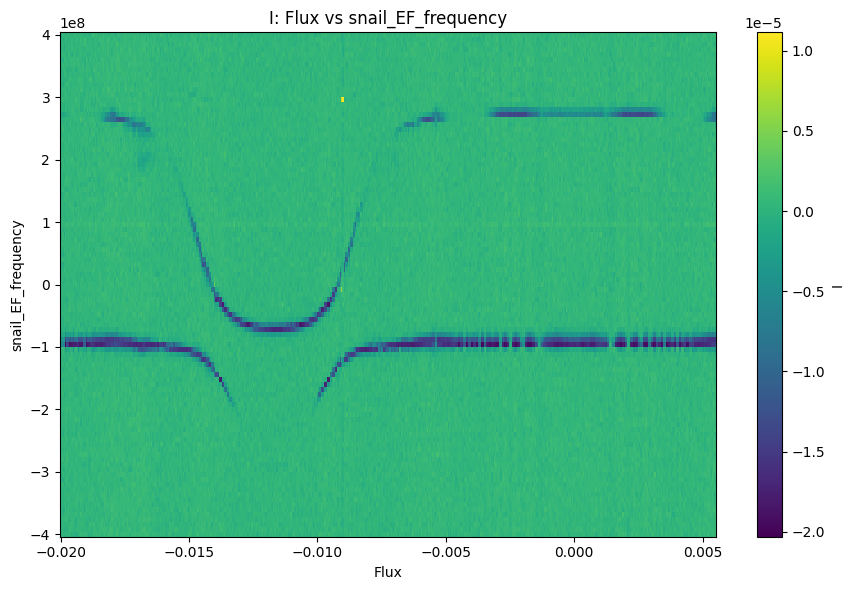

In [7]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# USER SETTINGS
# ==========================================================

# --- Define all batches here ---
batches = [
    {
        "folder": r"C:/Users/qcrew/Desktop/Juncheng/victoria/data/2026-07-18",
        "time": ((21,50), (23, 59)),
        "flux": np.linspace(start=-20e-3, stop=20e-3, num=801)[0:134],
    },
    {
        "folder": r"C:/Users/qcrew/Desktop/Juncheng/victoria/data/2026-07-19",
        "time": ((0, 0), (7, 0)),
        "flux": np.linspace(start=-20e-3, stop=20e-3, num=801)[134:134+377],
    },
]

file_key = "snail_spec_threetone_cavspec_versus_flux_EF"

plot_data = "I"          # "I", "Q", or "MAG"
y_key = None             # None -> automatically choose first dataset
show_individual_plots = False

x_label = "Flux"

# ==========================================================
# HELPER FUNCTIONS
# ==========================================================

def extract_time(filename):
    try:
        parts = filename.split("-")
        return (int(parts[0]), int(parts[1]))
    except:
        return (-1, -1)


def get_filtered_files(folder, start_time, end_time):

    selected = []

    if not os.path.exists(folder):
        print(f"Folder not found: {folder}")
        return selected

    for filename in os.listdir(folder):

        if not filename.endswith(".hdf5"):
            continue

        if file_key not in filename:
            continue

        t = extract_time(filename)

        if start_time <= t <= end_time:
            selected.append(os.path.join(folder, filename))

    selected.sort()

    return selected


# ==========================================================
# COLLECT FILES FROM ALL BATCHES
# ==========================================================

grouped_filenames = []
x_values = []

for batch in batches:

    folder = batch["folder"]
    start_time, end_time = batch["time"]

    files = get_filtered_files(folder, start_time, end_time)

    print(f"\nBatch: {folder}")
    print(f"Found {len(files)} files")

    if len(files) != len(batch["flux"]):
        print(
            f"WARNING: {len(files)} files but {len(batch['flux'])} flux values."
        )

    n = min(len(files), len(batch["flux"]))

    grouped_filenames.extend(files[:n])
    x_values.extend(batch["flux"][:n])

if len(grouped_filenames) == 0:
    raise ValueError("No files found.")

x_values = np.array(x_values)

print(f"\nTotal files loaded: {len(grouped_filenames)}")

# ==========================================================
# DISPLAY AVAILABLE KEYS
# ==========================================================

with h5py.File(grouped_filenames[0], "r") as f:

    print("\nAvailable keys:")

    for k in f.keys():
        print(" ", k)

# ==========================================================
# EXTRACT DATA
# ==========================================================

sweep_axis = []
data_2d = []

for i, filename in enumerate(grouped_filenames):

    print(f"Loading ({i+1}/{len(grouped_filenames)}): {os.path.basename(filename)}")

    with h5py.File(filename, "r") as f:

        # ----------------------------------
        # Sweep axis
        # ----------------------------------

        if y_key is None:
            key = list(f.keys())[0]
        else:
            key = y_key

        y_values = np.array(f[key][()])

        # ----------------------------------
        # Channels
        # ----------------------------------

        I_values = np.mean(f["I"][()], axis=0)
        I_values -= np.mean(I_values)

        Q_values = np.mean(f["Q"][()], axis=0)
        Q_values -= np.mean(Q_values)

        MAG_values = np.mean(f["Magnitude"][()], axis=0)
        MAG_values -= np.mean(MAG_values)

        channel_dict = {
            "I": I_values,
            "Q": Q_values,
            "MAG": MAG_values,
        }

        selected_data = channel_dict[plot_data]

        sweep_axis.append(y_values)
        data_2d.append(selected_data)

        # ----------------------------------
        # Optional individual plots
        # ----------------------------------

        if show_individual_plots:

            plt.figure(figsize=(8,4))

            plt.plot(y_values, selected_data)

            plt.xlabel(key)
            plt.ylabel(plot_data)
            plt.title(f"{plot_data}, {x_label} = {x_values[i]:.6f}")

            plt.grid(True)
            plt.tight_layout()
            plt.show()

# ==========================================================
# CONVERT TO ARRAYS
# ==========================================================

sweep_axis = np.array(sweep_axis)
data_2d = np.array(data_2d)

print("Data shape:", data_2d.shape)

# ==========================================================
# 2D COLORMAP
# ==========================================================

plt.figure(figsize=(9,6))

plt.pcolormesh(
    x_values,
    sweep_axis[0],
    data_2d.T,
    shading="auto",
    cmap="viridis",
)

plt.xlabel(x_label)
plt.ylabel(key)
plt.title(f"{plot_data}: {x_label} vs {key}")

plt.colorbar(label=plot_data)

plt.tight_layout()
plt.show()

Saved main NPZ to: C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data\RRSpec_versusflux_20260705_1315_to_20260705_1320_MAG.npz


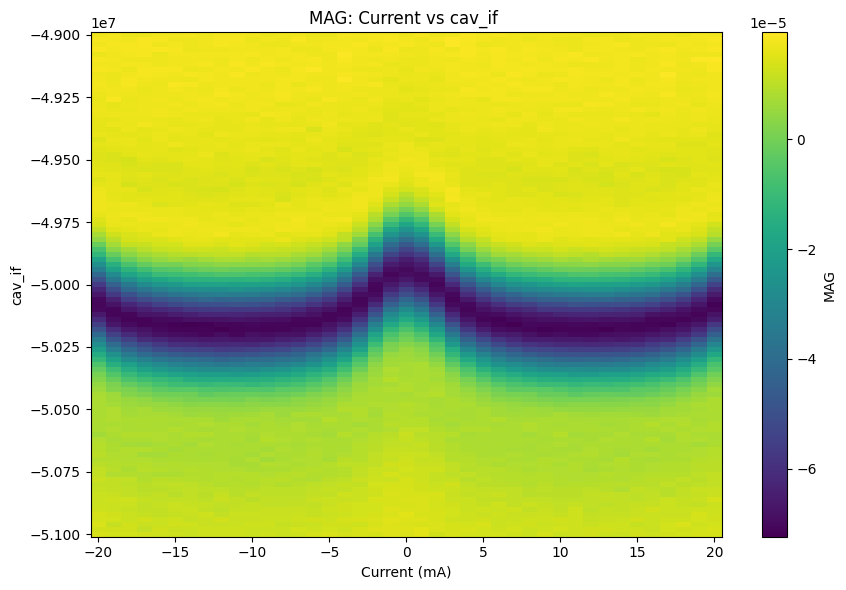

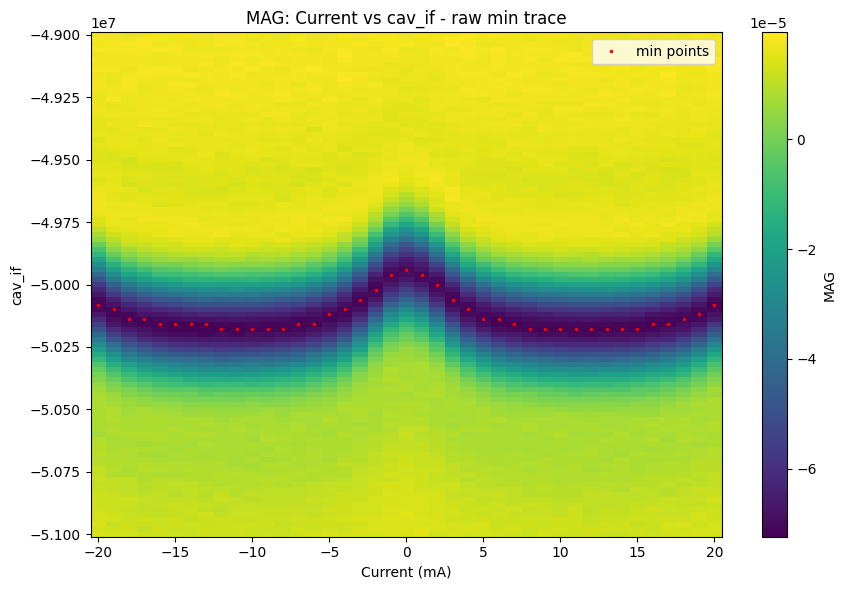

Saved raw trace NPZ to: C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data\RRSpec_versusflux_20260705_1315_to_20260705_1320_MAG_raw_min_trace.npz

current = [-20, -19, -18, -17, -16, -15, -14, -13, -12, -11, -10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

cav_if = [-50080000, -50100000, -50140000, -50140000, -50160000, -50160000, -50160000, -50160000, -50180000, -50180000, -50180000, -50180000, -50180000, -50160000, -50160000, -50120000, -50100000, -50060000, -50020000, -49960000, -49940000, -49960000, -50000000, -50060000, -50100000, -50140000, -50140000, -50160000, -50180000, -50180000, -50180000, -50180000, -50180000, -50180000, -50180000, -50180000, -50160000, -50160000, -50140000, -50120000, -50080000]


In [21]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# USER SETTINGS
# ==========================================================
build_npz_from_hdf5 = True
load_npz_for_analysis = True
current_A_print = np.linspace(start=-20e-3, stop=20e-3, num=41)
batches = [
    {
        "date": "2026-07-05",
        "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-07",
        "time": ((13, 15), (13, 20)),
        "current": current_A_print
    },
]

file_key = "RRSpec_versusflux"
plot_data = "MAG"          # "I", "Q", or "MAG"
y_key = None             # None -> auto-choose sweep axis
subtract_mean = True
x_label, y_label = "Current", "cav_if"
show_individual_plots = False
plot_current_in_mA = True
output_folder = r"C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data"
os.makedirs(output_folder, exist_ok=True)

# Generate names dynamically
st_d, end_d = batches[0]["date"].replace("-", ""), batches[-1]["date"].replace("-", "")
st_h, st_m = batches[0]["time"][0]
end_h, end_m = batches[-1]["time"][1]
save_npz_name = f"{file_key}_{st_d}_{st_h:02d}{st_m:02d}_to_{end_d}_{end_h:02d}{end_m:02d}_{plot_data}.npz"
npz_path = os.path.join(output_folder, save_npz_name)

# Trace Settings
find_mode = "min"        # "min" or "max"
save_min_trace = True

# ==========================================================
# HELPER FUNCTIONS
# ==========================================================

def extract_time(filename):
    try:
        parts = os.path.basename(filename).split("-")
        return (int(parts[0]), int(parts[1]))
    except Exception:
        return (-1, -1)

def get_filtered_files(folder, start_time, end_time, file_key):
    if not os.path.exists(folder):
        print(f"Folder not found: {folder}")
        return []
    files = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(".hdf5") and file_key in f]
    return sorted([f for f in files if start_time <= extract_time(f) <= end_time])

def load_one_hdf5(filename, y_key=None, subtract_mean=True):
    with h5py.File(filename, "r") as f:
        key = y_key or next(k for k in f.keys() if k not in {"I", "Q", "Magnitude"})
        y_vals = np.array(f[key][()])
        
        # Flatten array averages instantly
        I_val = np.mean(f["I"][()], axis=0) if f["I"].ndim > 1 else np.array(f["I"][()])
        Q_val = np.mean(f["Q"][()], axis=0) if f["Q"].ndim > 1 else np.array(f["Q"][()])
        mag_val = np.mean(f["Magnitude"][()], axis=0) if "Magnitude" in f.keys() else np.sqrt(I_val**2 + Q_val**2)

        if subtract_mean:
            I_val -= np.mean(I_val)
            Q_val -= np.mean(Q_val)
            mag_val -= np.mean(mag_val)
            
    return key, y_vals, I_val, Q_val, mag_val

def base_mesh_plot(x, y, z, title_suffix=""):
    """Consolidated 2D Mesh plotting template to remove duplicate code block."""
    plt.figure(figsize=(9, 6))
    x_plot = x * 1e3 if plot_current_in_mA else x
    plt.pcolormesh(x_plot, y, z.T, shading="auto", cmap="viridis")
    plt.xlabel(f"{x_label} ({'mA' if plot_current_in_mA else 'A'})")
    plt.ylabel(y_label)
    plt.title(f"{plot_data}: {x_label} vs {y_label} {title_suffix}")
    plt.colorbar(label=plot_data)
    plt.tight_layout()

# ==========================================================
# PROCESSING & ANALYSIS
# ==========================================================

if build_npz_from_hdf5:
    grouped_files, x_values, file_dates, file_times = [], [], [], []
    
    for b in batches:
        files = get_filtered_files(b["folder"], b["time"][0], b["time"][1], file_key)
        n = min(len(files), len(b["current"]))
        
        grouped_files.extend(files[:n])
        x_values.extend(b["current"][:n])
        file_dates.extend([b["date"]] * n)
        file_times.extend([extract_time(f) for f in files[:n]])

    if not grouped_files:
        raise ValueError("No matching HDF5 files found.")

    I_2d, Q_2d, MAG_2d, sweep_axis = [], [], [], []
    for i, fname in enumerate(grouped_files):
        key, y_vals, I_v, Q_v, M_v = load_one_hdf5(fname, y_key, subtract_mean)
        sweep_axis.append(y_vals)
        I_2d.append(I_v)
        Q_2d.append(Q_v)
        MAG_2d.append(M_v)

    y_values = sweep_axis[0]
    
    np.savez_compressed(
        npz_path, x_values=x_values, current=x_values, current_mA=np.array(x_values)*1e3,
        y_values=y_values, cav_if=y_values, sweep_axis=sweep_axis, I=I_2d, Q=Q_2d, MAG=MAG_2d,
        x_label=x_label, y_label=y_label, y_key=key, filenames=grouped_files, 
        file_dates=file_dates, file_times=file_times, batch_dates=[b["date"] for b in batches],
        batch_start_times=[b["time"][0] for b in batches], batch_end_times=[b["time"][1] for b in batches],
        batch_folders=[b["folder"] for b in batches], file_key=file_key, subtract_mean=subtract_mean, plot_data_saved=plot_data
    )
    print(f"Saved main NPZ to: {npz_path}")

if load_npz_for_analysis:
    data = np.load(npz_path, allow_pickle=True)
    x_values = data["current"]
    y_values = data["cav_if"] if "cav_if" in data.keys() else data["y_values"]
    data_2d = data[plot_data]

    # Raw 2D Mesh Plot
    base_mesh_plot(x_values, y_values, data_2d)
    plt.show()

    # Find Min/Max Trace & Plot Overlay
    idx = np.argmin(data_2d, axis=1) if find_mode == "min" else np.argmax(data_2d, axis=1)
    trace_y, trace_val = y_values[idx], data_2d[np.arange(data_2d.shape[0]), idx]

    base_mesh_plot(x_values, y_values, data_2d, f"- raw {find_mode} trace")
    plt.plot(x_values * 1e3 if plot_current_in_mA else x_values, trace_y, "r.", markersize=3, label=f"{find_mode} points")
    plt.legend()
    plt.show()

    # Save Raw Trace
    if save_min_trace:
        save_trace_name = save_npz_name.replace(".npz", f"_raw_{find_mode}_trace.npz")
        np.savez_compressed(
            os.path.join(output_folder, save_trace_name),
            current=x_values, current_mA=x_values*1e3, cav_if=trace_y, value=trace_val,
            plot_data=plot_data, find_mode=find_mode
        )
        print(f"Saved raw trace NPZ to: {os.path.join(output_folder, save_trace_name)}")

    # Final Printout
    print(f"\ncurrent = [{', '.join(f'{x*1e3:.9g}' for x in x_values)}]")
    print(f"\ncav_if = [{', '.join(f'{y:.9g}' for y in trace_y)}]")

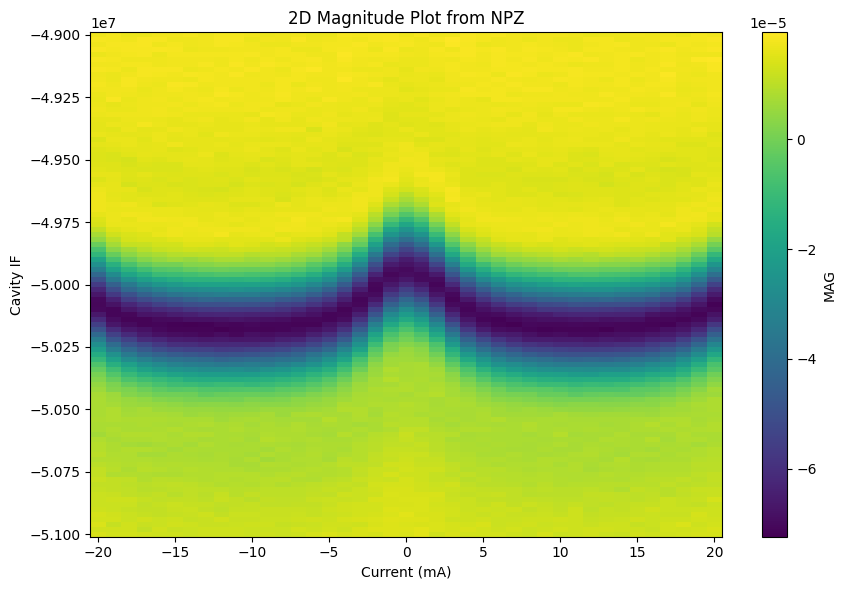

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the main 2D NPZ file
file_path = r"C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data\RRSpec_versusflux_20260705_1315_to_20260705_1320_MAG.npz"
data = np.load(file_path, allow_pickle=True)

# 2. Extract axes and the 2D array
x = data["current_mA"]
y = data["cav_if"]
Z = data["MAG"]  # Extract the 2D magnitude data

# 3. Create the 2D plot
plt.figure(figsize=(9, 6))
# We use np.array(Z.tolist()) to ensure it behaves correctly if it was saved as an object array
Z_array = np.array(Z.tolist()) 

plt.pcolormesh(x, y, Z_array.T, shading="auto", cmap="viridis")

plt.xlabel("Current (mA)")
plt.ylabel("Cavity IF")
plt.title("2D Magnitude Plot from NPZ")
plt.colorbar(label="MAG")
plt.tight_layout()
plt.show()

data.close()

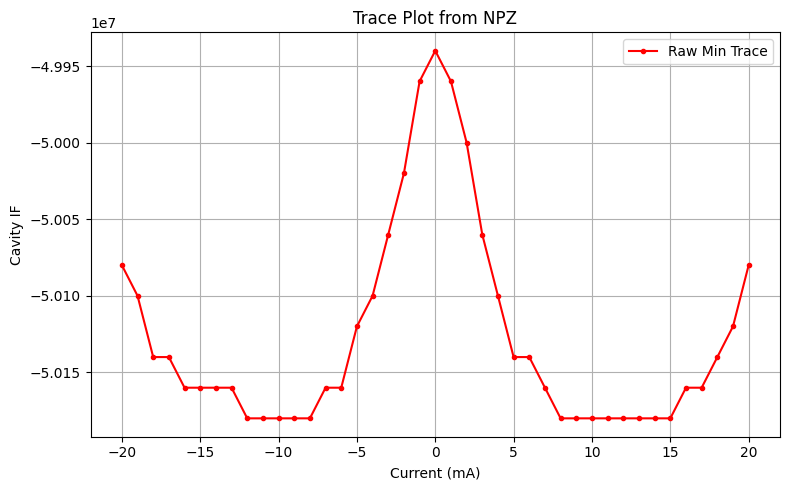

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Change the filename to the TRACE file
file_path = r"C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data\RRSpec_versusflux_20260705_1315_to_20260705_1320_MAG_raw_min_trace.npz"
data = np.load(file_path)

# 2. Extract the variables
x = data["current_mA"]
y = data["cav_if"]

# 3. Create the plot
plt.figure(figsize=(8, 5))
plt.plot(x, y, 'r.-', markersize=6, label="Raw Min Trace")

plt.xlabel("Current (mA)")
plt.ylabel("Cavity IF")
plt.title("Trace Plot from NPZ")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

data.close()


Batch: C:/Users/qcrew/Desktop/Juncheng/victoria/data/2026-07-04
Found 237 files

Batch: C:/Users/qcrew/Desktop/Juncheng/victoria/data/2026-07-05
Found 274 files

Total files loaded: 511

Available keys:
  snail_frequency
  I
  Q
  Magnitude
Loading (1/511): 19-06-51_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading (2/511): 19-08-07_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading (3/511): 19-09-22_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading (4/511): 19-10-37_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading (5/511): 19-11-50_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading (6/511): 19-13-05_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading (7/511): 19-14-19_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading (8/511): 19-15-33_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading (9/511): 19-16-48_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading (10/511): 19-18-03_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading (11/511): 19-19-17_SnailSpec_twotone_sideq_versus_flux.hdf5
Loading (12/511): 1

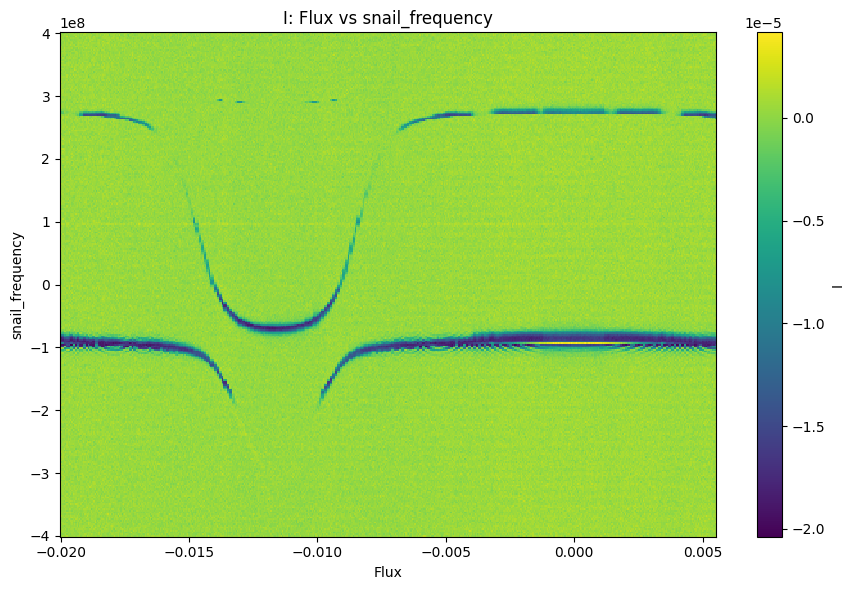

In [6]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# USER SETTINGS
# ==========================================================

# --- Define all batches here ---
batches = [
    {
        "folder": r"C:/Users/qcrew/Desktop/Juncheng/victoria/data/2026-07-04",
        "time": ((19,6), (23, 59)),
        "flux": np.linspace(start=-20e-3, stop=20e-3, num=801)[0:237],
    },
    {
        "folder": r"C:/Users/qcrew/Desktop/Juncheng/victoria/data/2026-07-05",
        "time": ((0, 0), (6, 0)),
        "flux": np.linspace(start=-20e-3, stop=20e-3, num=801)[237:237+274],
    },
]

file_key = "SnailSpec_twotone_sideq_versus_flu"

plot_data = "I"          # "I", "Q", or "MAG"
y_key = None             # None -> automatically choose first dataset
show_individual_plots = False

x_label = "Flux"

# ==========================================================
# HELPER FUNCTIONS
# ==========================================================

def extract_time(filename):
    try:
        parts = filename.split("-")
        return (int(parts[0]), int(parts[1]))
    except:
        return (-1, -1)


def get_filtered_files(folder, start_time, end_time):

    selected = []

    if not os.path.exists(folder):
        print(f"Folder not found: {folder}")
        return selected

    for filename in os.listdir(folder):

        if not filename.endswith(".hdf5"):
            continue

        if file_key not in filename:
            continue

        t = extract_time(filename)

        if start_time <= t <= end_time:
            selected.append(os.path.join(folder, filename))

    selected.sort()

    return selected


# ==========================================================
# COLLECT FILES FROM ALL BATCHES
# ==========================================================

grouped_filenames = []
x_values = []

for batch in batches:

    folder = batch["folder"]
    start_time, end_time = batch["time"]

    files = get_filtered_files(folder, start_time, end_time)

    print(f"\nBatch: {folder}")
    print(f"Found {len(files)} files")

    if len(files) != len(batch["flux"]):
        print(
            f"WARNING: {len(files)} files but {len(batch['flux'])} flux values."
        )

    n = min(len(files), len(batch["flux"]))

    grouped_filenames.extend(files[:n])
    x_values.extend(batch["flux"][:n])

if len(grouped_filenames) == 0:
    raise ValueError("No files found.")

x_values = np.array(x_values)

print(f"\nTotal files loaded: {len(grouped_filenames)}")

# ==========================================================
# DISPLAY AVAILABLE KEYS
# ==========================================================

with h5py.File(grouped_filenames[0], "r") as f:

    print("\nAvailable keys:")

    for k in f.keys():
        print(" ", k)

# ==========================================================
# EXTRACT DATA
# ==========================================================

sweep_axis = []
data_2d = []

for i, filename in enumerate(grouped_filenames):

    print(f"Loading ({i+1}/{len(grouped_filenames)}): {os.path.basename(filename)}")

    with h5py.File(filename, "r") as f:

        # ----------------------------------
        # Sweep axis
        # ----------------------------------

        if y_key is None:
            key = list(f.keys())[0]
        else:
            key = y_key

        y_values = np.array(f[key][()])

        # ----------------------------------
        # Channels
        # ----------------------------------

        I_values = np.mean(f["I"][()], axis=0)
        I_values -= np.mean(I_values)

        Q_values = np.mean(f["Q"][()], axis=0)
        Q_values -= np.mean(Q_values)

        MAG_values = np.mean(f["Magnitude"][()], axis=0)
        MAG_values -= np.mean(MAG_values)

        channel_dict = {
            "I": I_values,
            "Q": Q_values,
            "MAG": MAG_values,
        }

        selected_data = channel_dict[plot_data]

        sweep_axis.append(y_values)
        data_2d.append(selected_data)

        # ----------------------------------
        # Optional individual plots
        # ----------------------------------

        if show_individual_plots:

            plt.figure(figsize=(8,4))

            plt.plot(y_values, selected_data)

            plt.xlabel(key)
            plt.ylabel(plot_data)
            plt.title(f"{plot_data}, {x_label} = {x_values[i]:.6f}")

            plt.grid(True)
            plt.tight_layout()
            plt.show()

# ==========================================================
# CONVERT TO ARRAYS
# ==========================================================

sweep_axis = np.array(sweep_axis)
data_2d = np.array(data_2d)

print("Data shape:", data_2d.shape)

# ==========================================================
# 2D COLORMAP
# ==========================================================

plt.figure(figsize=(9,6))

plt.pcolormesh(
    x_values,
    sweep_axis[0],
    data_2d.T,
    shading="auto",
    cmap="viridis",
)

plt.xlabel(x_label)
plt.ylabel(key)
plt.title(f"{plot_data}: {x_label} vs {key}")

plt.colorbar(label=plot_data)

plt.tight_layout()
plt.show()


Batch: C:/Users/qcrew/Desktop/Juncheng/victoria/data/2026-07-19
Found 511 files

Total files loaded: 511

Available keys:
  snail_EF_frequency
  I
  Q
  Magnitude
Loading (1/511): 08-20-16_snail_spec_threetone_cavspec_versus_flux_EF.hdf5
Loading (2/511): 08-21-11_snail_spec_threetone_cavspec_versus_flux_EF.hdf5
Loading (3/511): 08-22-06_snail_spec_threetone_cavspec_versus_flux_EF.hdf5
Loading (4/511): 08-23-01_snail_spec_threetone_cavspec_versus_flux_EF.hdf5
Loading (5/511): 08-23-57_snail_spec_threetone_cavspec_versus_flux_EF.hdf5
Loading (6/511): 08-24-52_snail_spec_threetone_cavspec_versus_flux_EF.hdf5
Loading (7/511): 08-25-47_snail_spec_threetone_cavspec_versus_flux_EF.hdf5
Loading (8/511): 08-26-43_snail_spec_threetone_cavspec_versus_flux_EF.hdf5
Loading (9/511): 08-27-39_snail_spec_threetone_cavspec_versus_flux_EF.hdf5
Loading (10/511): 08-28-35_snail_spec_threetone_cavspec_versus_flux_EF.hdf5
Loading (11/511): 08-29-30_snail_spec_threetone_cavspec_versus_flux_EF.hdf5
Loading (

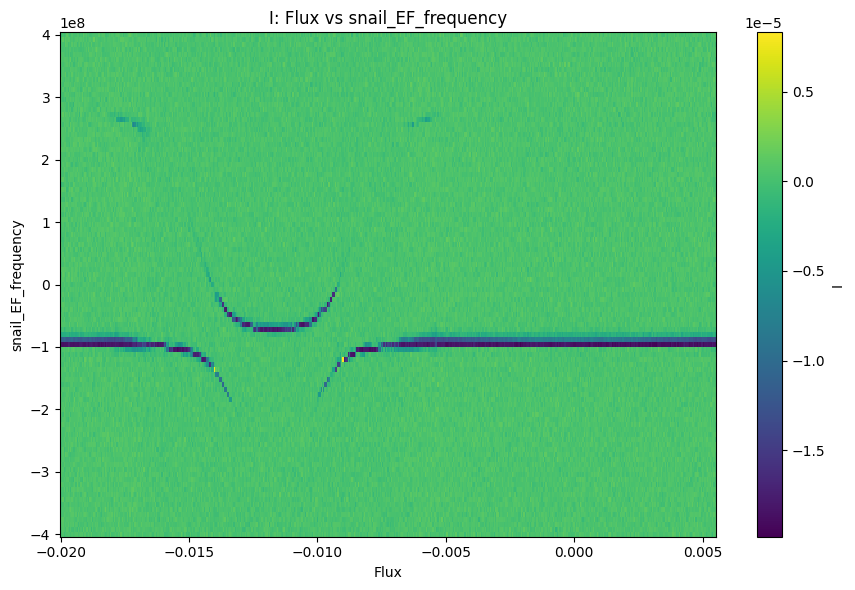

In [9]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# USER SETTINGS
# ==========================================================

# --- Define all batches here ---
batches = [
    {
        "folder": r"C:/Users/qcrew/Desktop/Juncheng/victoria/data/2026-07-19",
        "time": ((8,00), (23, 59)),
        "flux": np.linspace(start=-20e-3, stop=20e-3, num=801)[0:511],
    },
    # {
    #     "folder": r"C:/Users/qcrew/Desktop/Juncheng/victoria/data/2026-07-19",
    #     "time": ((0, 0), (7, 0)),
    #     "flux": np.linspace(start=-20e-3, stop=20e-3, num=801)[134:134+377],
    # },
]

file_key = "snail_spec_threetone_cavspec_versus_flux_EF"

plot_data = "I"          # "I", "Q", or "MAG"
y_key = None             # None -> automatically choose first dataset
show_individual_plots = False

x_label = "Flux"

# ==========================================================
# HELPER FUNCTIONS
# ==========================================================

def extract_time(filename):
    try:
        parts = filename.split("-")
        return (int(parts[0]), int(parts[1]))
    except:
        return (-1, -1)


def get_filtered_files(folder, start_time, end_time):

    selected = []

    if not os.path.exists(folder):
        print(f"Folder not found: {folder}")
        return selected

    for filename in os.listdir(folder):

        if not filename.endswith(".hdf5"):
            continue

        if file_key not in filename:
            continue

        t = extract_time(filename)

        if start_time <= t <= end_time:
            selected.append(os.path.join(folder, filename))

    selected.sort()

    return selected


# ==========================================================
# COLLECT FILES FROM ALL BATCHES
# ==========================================================

grouped_filenames = []
x_values = []

for batch in batches:

    folder = batch["folder"]
    start_time, end_time = batch["time"]

    files = get_filtered_files(folder, start_time, end_time)

    print(f"\nBatch: {folder}")
    print(f"Found {len(files)} files")

    if len(files) != len(batch["flux"]):
        print(
            f"WARNING: {len(files)} files but {len(batch['flux'])} flux values."
        )

    n = min(len(files), len(batch["flux"]))

    grouped_filenames.extend(files[:n])
    x_values.extend(batch["flux"][:n])

if len(grouped_filenames) == 0:
    raise ValueError("No files found.")

x_values = np.array(x_values)

print(f"\nTotal files loaded: {len(grouped_filenames)}")

# ==========================================================
# DISPLAY AVAILABLE KEYS
# ==========================================================

with h5py.File(grouped_filenames[0], "r") as f:

    print("\nAvailable keys:")

    for k in f.keys():
        print(" ", k)

# ==========================================================
# EXTRACT DATA
# ==========================================================

sweep_axis = []
data_2d = []

for i, filename in enumerate(grouped_filenames):

    print(f"Loading ({i+1}/{len(grouped_filenames)}): {os.path.basename(filename)}")

    with h5py.File(filename, "r") as f:

        # ----------------------------------
        # Sweep axis
        # ----------------------------------

        if y_key is None:
            key = list(f.keys())[0]
        else:
            key = y_key

        y_values = np.array(f[key][()])

        # ----------------------------------
        # Channels
        # ----------------------------------

        I_values = np.mean(f["I"][()], axis=0)
        I_values -= np.mean(I_values)

        Q_values = np.mean(f["Q"][()], axis=0)
        Q_values -= np.mean(Q_values)

        MAG_values = np.mean(f["Magnitude"][()], axis=0)
        MAG_values -= np.mean(MAG_values)

        channel_dict = {
            "I": I_values,
            "Q": Q_values,
            "MAG": MAG_values,
        }

        selected_data = channel_dict[plot_data]

        sweep_axis.append(y_values)
        data_2d.append(selected_data)

        # ----------------------------------
        # Optional individual plots
        # ----------------------------------

        if show_individual_plots:

            plt.figure(figsize=(8,4))

            plt.plot(y_values, selected_data)

            plt.xlabel(key)
            plt.ylabel(plot_data)
            plt.title(f"{plot_data}, {x_label} = {x_values[i]:.6f}")

            plt.grid(True)
            plt.tight_layout()
            plt.show()

# ==========================================================
# CONVERT TO ARRAYS
# ==========================================================

sweep_axis = np.array(sweep_axis)
data_2d = np.array(data_2d)

print("Data shape:", data_2d.shape)

# ==========================================================
# 2D COLORMAP
# ==========================================================

plt.figure(figsize=(9,6))

plt.pcolormesh(
    x_values,
    sweep_axis[0],
    data_2d.T,
    shading="auto",
    cmap="viridis",
)

plt.xlabel(x_label)
plt.ylabel(key)
plt.title(f"{plot_data}: {x_label} vs {key}")

plt.colorbar(label=plot_data)

plt.tight_layout()
plt.show()

Saved main NPZ to: C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data\CavitySpec_versus_flux_20260703_1810_to_20260704_1400_I.npz


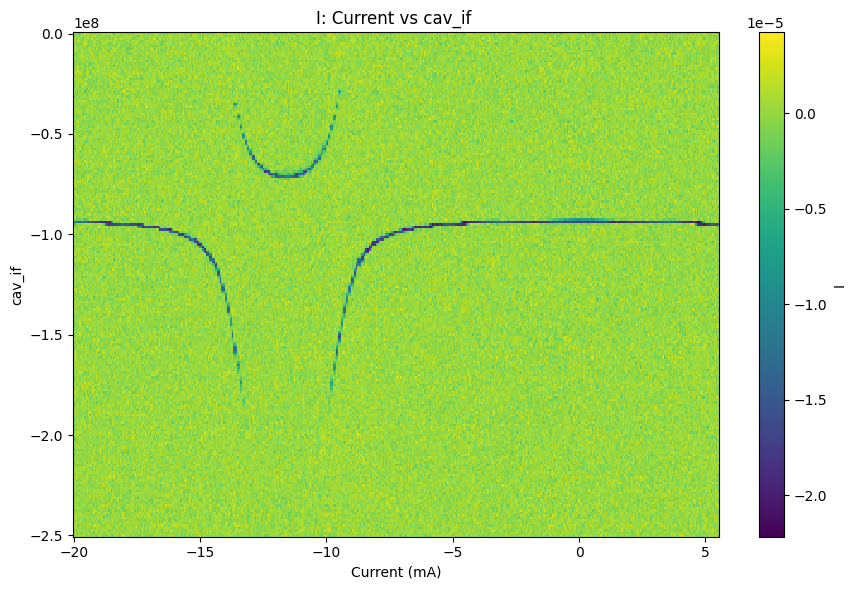

Empty columns needing interpolation: 0 out of 511
Detected 77 jump location(s) at current(s): [-18.8  -17.5  -16.65 -16.25 -15.9  -15.65 -15.45 -15.25 -15.15 -15.05 -14.95 -14.85 -14.8  -14.65 -14.55 -14.45 -14.35
 -14.25 -14.2  -14.1  -14.05 -13.95 -13.85 -13.75 -13.7  -13.55 -13.45 -13.35 -13.25 -13.15 -13.1  -12.95 -12.85 -12.75
 -12.7  -12.55 -12.5  -12.35 -12.05 -11.3  -10.95 -10.8  -10.65 -10.55 -10.5  -10.35 -10.25 -10.2  -10.05  -9.95  -9.9
  -9.75  -9.65  -9.55  -9.45  -9.35  -9.25  -9.15  -9.05  -8.95  -8.85  -8.8   -8.65  -8.55  -8.5   -8.35  -8.25  -8.2
  -8.05  -7.9   -7.65  -7.45  -7.05  -6.65  -5.95  -4.75   4.85] mA


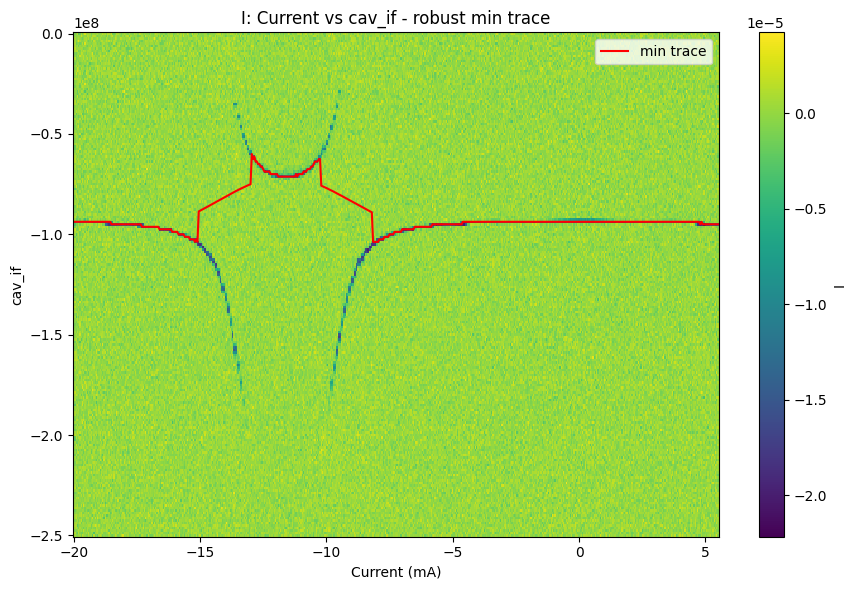

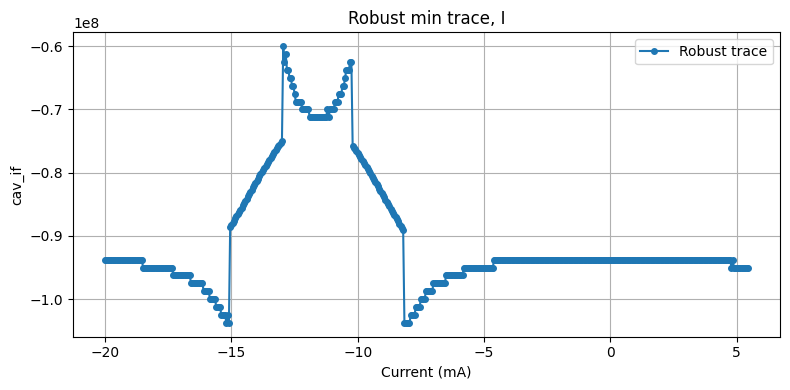

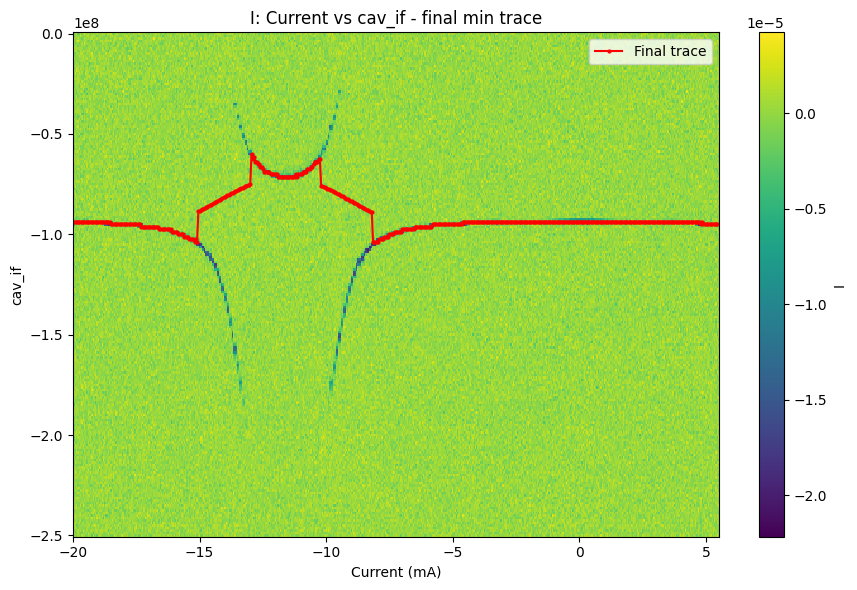


current = [-0.02, -0.01995, -0.0199, -0.01985, -0.0198, -0.01975, -0.0197, -0.01965, -0.0196, -0.01955, -0.0195, -0.01945, -0.0194, -0.01935, -0.0193, -0.01925, -0.0192, -0.01915, -0.0191, -0.01905, -0.019, -0.01895, -0.0189, -0.01885, -0.0188, -0.01875, -0.0187, -0.01865, -0.0186, -0.01855, -0.0185, -0.01845, -0.0184, -0.01835, -0.0183, -0.01825, -0.0182, -0.01815, -0.0181, -0.01805, -0.018, -0.01795, -0.0179, -0.01785, -0.0178, -0.01775, -0.0177, -0.01765, -0.0176, -0.01755, -0.0175, -0.01745, -0.0174, -0.01735, -0.0173, -0.01725, -0.0172, -0.01715, -0.0171, -0.01705, -0.017, -0.01695, -0.0169, -0.01685, -0.0168, -0.01675, -0.0167, -0.01665, -0.0166, -0.01655, -0.0165, -0.01645, -0.0164, -0.01635, -0.0163, -0.01625, -0.0162, -0.01615, -0.0161, -0.01605, -0.016, -0.01595, -0.0159, -0.01585, -0.0158, -0.01575, -0.0157, -0.01565, -0.0156, -0.01555, -0.0155, -0.01545, -0.0154, -0.01535, -0.0153, -0.01525, -0.0152, -0.01515, -0.0151, -0.01505, -0.015, -0.01495, -0.0149, -0.01485, -0.0148

In [22]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
from scipy.interpolate import PchipInterpolator

# ==========================================================
# USER SETTINGS
# ==========================================================
build_npz_from_hdf5 = True
load_npz_for_analysis = True

batches = [
    {
        "date": "2026-07-03",
        "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-03",
        "time": ((18, 10), (23, 59)),
        "current": np.linspace(start=-20e-3, stop=20e-3, num=801)[0:248],
    },
    {
        "date": "2026-07-04",
        "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-07-04",
        "time": ((0, 0), (14, 0)),
        "current": np.linspace(start=-20e-3, stop=20e-3, num=801)[248:248+263],
    },
]

file_key = "CavitySpec_versus_flux"
plot_data = "I"          # "I", "Q", or "MAG"
y_key = None              # None -> auto-choose sweep axis
subtract_mean = True
x_label, y_label = "Current", "cav_if"
show_individual_plots = False
plot_current_in_mA = True
output_folder = r"C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data"
os.makedirs(output_folder, exist_ok=True)

# Generate names dynamically
st_d, end_d = batches[0]["date"].replace("-", ""), batches[-1]["date"].replace("-", "")
st_h, st_m = batches[0]["time"][0]
end_h, end_m = batches[-1]["time"][1]
save_npz_name = f"{file_key}_{st_d}_{st_h:02d}{st_m:02d}_to_{end_d}_{end_h:02d}{end_m:02d}_{plot_data}.npz"
npz_path = os.path.join(output_folder, save_npz_name)

# Trace & Outlier Settings
find_mode = "min"        # "min" or "max"
current_min_mA, current_max_mA = -20, 5.5
save_min_trace = True

# --- Robust trace extraction settings ---
dip_threshold = -0.5e-5   # tune to your colorbar; sign convention handled automatically below
refine_window = 1.5e7     # cav_if window (Hz) for the local argmin/argmax refinement pass
half_window = 6           # columns on each side of a detected jump to smooth through
jump_multiplier = 8       # how many x the median step must be exceeded to count as a "jump"
smooth_size = 5           # uniform_filter1d window for final light smoothing

# ==========================================================
# HELPER FUNCTIONS
# ==========================================================

def extract_time(filename):
    try:
        parts = os.path.basename(filename).split("-")
        return (int(parts[0]), int(parts[1]))
    except Exception:
        return (-1, -1)

def get_filtered_files(folder, start_time, end_time, file_key):
    if not os.path.exists(folder):
        print(f"Folder not found: {folder}")
        return []
    files = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(".hdf5") and file_key in f]
    return sorted([f for f in files if start_time <= extract_time(f) <= end_time])

def load_one_hdf5(filename, y_key=None, subtract_mean=True):
    with h5py.File(filename, "r") as f:
        key = y_key or next(k for k in f.keys() if k not in {"I", "Q", "Magnitude"})
        y_vals = np.array(f[key][()])

        I_val = np.mean(f["I"][()], axis=0) if f["I"].ndim > 1 else np.array(f["I"][()])
        Q_val = np.mean(f["Q"][()], axis=0) if f["Q"].ndim > 1 else np.array(f["Q"][()])
        mag_val = np.mean(f["Magnitude"][()], axis=0) if "Magnitude" in f.keys() else np.sqrt(I_val**2 + Q_val**2)

        if subtract_mean:
            I_val -= np.mean(I_val)
            Q_val -= np.mean(Q_val)
            mag_val -= np.mean(mag_val)

    return key, y_vals, I_val, Q_val, mag_val

def base_mesh_plot(x, y, z, title_suffix=""):
    """Consolidated 2D Mesh plotting template to remove duplicate code block."""
    plt.figure(figsize=(9, 6))
    x_plot = x * 1e3 if plot_current_in_mA else x
    plt.pcolormesh(x_plot, y, z.T, shading="auto", cmap="viridis")
    plt.xlabel(f"{x_label} ({'mA' if plot_current_in_mA else 'A'})")
    plt.ylabel(y_label)
    plt.title(f"{plot_data}: {x_label} vs {y_label} {title_suffix}")
    plt.colorbar(label=plot_data)
    plt.tight_layout()

def extract_robust_trace(x_values, y_values, data_2d, find_mode="min", threshold=-0.5e-5,
                          refine_window=1.5e7, half_window=6, jump_multiplier=8, smooth_size=5):
    """
    Ridge-following trace extraction with gap-filling, de-kinking, and local refinement.
    Returns trace_y (cav_if values, same length as x_values) and trace_val (signal at those points).
    """
    n_curr = len(x_values)
    thr = threshold if find_mode == "min" else -threshold  # flip convention for "max" mode

    def passes(val):
        return val < thr if find_mode == "min" else val > thr

    trace_y = np.full(n_curr, np.nan)

    # --- Seed at the most extreme point overall ---
    seed_idx = np.argmin(np.min(data_2d, axis=1)) if find_mode == "min" \
               else np.argmax(np.max(data_2d, axis=1))
    seed_col = data_2d[seed_idx, :]
    trace_y[seed_idx] = y_values[np.argmin(seed_col)] if find_mode == "min" \
                        else y_values[np.argmax(seed_col)]

    # --- Nearest-neighbor tracking, no distance cap ---
    def track_direction(indices):
        prev = trace_y[seed_idx]
        for i in indices:
            col = data_2d[i, :]
            cand = np.where(passes(col))[0]
            if len(cand) == 0:
                continue
            best = cand[np.argmin(np.abs(y_values[cand] - prev))]
            trace_y[i] = y_values[best]
            prev = y_values[best]

    track_direction(range(seed_idx - 1, -1, -1))
    track_direction(range(seed_idx + 1, n_curr))

    # --- Fill any empty columns ---
    valid = ~np.isnan(trace_y)
    print(f"Empty columns needing interpolation: {(~valid).sum()} out of {n_curr}")
    trace_filled = trace_y.copy()
    if (~valid).any():
        trace_filled[~valid] = np.interp(x_values[~valid], x_values[valid], trace_y[valid])

    # --- De-kink large jumps ---
    step_diff = np.abs(np.diff(trace_filled))
    typical_step = np.median(step_diff)
    jump_thr = jump_multiplier * typical_step
    jump_indices = np.where(step_diff > jump_thr)[0]
    print(f"Detected {len(jump_indices)} jump location(s) at current(s): {x_values[jump_indices] * 1e3} mA")

    trace_desmoothed = trace_filled.copy()
    for j in jump_indices:
        lo, hi = max(0, j - half_window), min(n_curr, j + half_window + 1)
        trace_desmoothed[lo:hi] = np.nan

    valid2 = ~np.isnan(trace_desmoothed)
    if (~valid2).any():
        pchip = PchipInterpolator(x_values[valid2], trace_desmoothed[valid2])
        trace_desmoothed[~valid2] = pchip(x_values[~valid2])

    trace_smoothed = uniform_filter1d(trace_desmoothed, size=smooth_size)

    # --- Refine onto local argmin/argmax where real signal exists ---
    trace_refined = trace_smoothed.copy()
    for i in range(n_curr):
        center = trace_refined[i]
        win_mask = np.abs(y_values - center) < refine_window
        if not np.any(win_mask):
            continue
        local_idx = np.where(win_mask)[0]
        col = data_2d[i, local_idx]
        best_local = local_idx[np.argmin(col)] if find_mode == "min" else local_idx[np.argmax(col)]
        if passes(data_2d[i, best_local]):
            trace_refined[i] = y_values[best_local]

    # --- Corresponding signal values at the trace (nearest y bin) ---
    y_idx = np.searchsorted(y_values, trace_refined).clip(0, len(y_values) - 1)
    # searchsorted can land one bin high; check the neighbor for a closer match
    y_idx_lo = (y_idx - 1).clip(0, len(y_values) - 1)
    use_lo = np.abs(y_values[y_idx_lo] - trace_refined) < np.abs(y_values[y_idx] - trace_refined)
    y_idx_final = np.where(use_lo, y_idx_lo, y_idx)
    trace_val = data_2d[np.arange(n_curr), y_idx_final]

    return trace_refined, trace_val

# ==========================================================
# PROCESSING & ANALYSIS
# ==========================================================

if build_npz_from_hdf5:
    grouped_files, x_values, file_dates, file_times = [], [], [], []

    for b in batches:
        files = get_filtered_files(b["folder"], b["time"][0], b["time"][1], file_key)
        n = min(len(files), len(b["current"]))

        grouped_files.extend(files[:n])
        x_values.extend(b["current"][:n])
        file_dates.extend([b["date"]] * n)
        file_times.extend([extract_time(f) for f in files[:n]])

    if not grouped_files:
        raise ValueError("No matching HDF5 files found.")

    I_2d, Q_2d, MAG_2d, sweep_axis = [], [], [], []
    for i, fname in enumerate(grouped_files):
        key, y_vals, I_v, Q_v, M_v = load_one_hdf5(fname, y_key, subtract_mean)
        sweep_axis.append(y_vals)
        I_2d.append(I_v)
        Q_2d.append(Q_v)
        MAG_2d.append(M_v)

    y_values = sweep_axis[0]

    np.savez_compressed(
        npz_path, x_values=x_values, current=x_values, current_mA=np.array(x_values) * 1e3,
        y_values=y_values, cav_if=y_values, sweep_axis=sweep_axis, I=I_2d, Q=Q_2d, MAG=MAG_2d,
        x_label=x_label, y_label=y_label, y_key=key, filenames=grouped_files,
        file_dates=file_dates, file_times=file_times, batch_dates=[b["date"] for b in batches],
        batch_start_times=[b["time"][0] for b in batches], batch_end_times=[b["time"][1] for b in batches],
        batch_folders=[b["folder"] for b in batches], file_key=file_key, subtract_mean=subtract_mean, plot_data_saved=plot_data
    )
    print(f"Saved main NPZ to: {npz_path}")

if load_npz_for_analysis:
    data = np.load(npz_path, allow_pickle=True)
    x_values = data["current"]
    y_values = data["cav_if"] if "cav_if" in data.keys() else data["y_values"]
    data_2d = data[plot_data]

    # Step 3: Raw 2D Mesh Plot
    base_mesh_plot(x_values, y_values, data_2d)
    plt.show()

    # Step 4 & 5: Robust trace extraction (ridge-following + gap fill + de-kink + refine)
    trace_y, trace_val = extract_robust_trace(
        x_values, y_values, data_2d,
        find_mode=find_mode,
        threshold=dip_threshold,
        refine_window=refine_window,
        half_window=half_window,
        jump_multiplier=jump_multiplier,
        smooth_size=smooth_size,
    )

    base_mesh_plot(x_values, y_values, data_2d, f"- robust {find_mode} trace")
    plt.plot(x_values * 1e3 if plot_current_in_mA else x_values, trace_y, "r-", linewidth=1.5, label=f"{find_mode} trace")
    plt.legend()
    plt.show()

    # Step 6: Filter Range
    mask = (x_values * 1e3 >= current_min_mA) & (x_values * 1e3 <= current_max_mA)
    x_clean = x_values[mask]
    cav_if_clean = trace_y[mask]
    value_clean = trace_val[mask]

    # Step 8: Plot Profile Verification
    plt.figure(figsize=(8, 4))
    plt.plot(x_clean * 1e3, cav_if_clean, "o-", markersize=4, label="Robust trace")
    plt.grid(True); plt.legend(); plt.xlabel("Current (mA)"); plt.ylabel("cav_if")
    plt.title(f"Robust {find_mode} trace, {plot_data}")
    plt.tight_layout()
    plt.show()

    # Step 9: Cleaned 2D Focus Plot
    base_mesh_plot(x_values, y_values, data_2d, f"- final {find_mode} trace")
    plt.plot(x_clean * 1e3, cav_if_clean, "r.-", markersize=4, label="Final trace")
    plt.xlim(current_min_mA, current_max_mA)
    plt.legend()
    plt.show()

    # Step 10: Save Cleaned Data
    if save_min_trace:
        save_min_name = save_npz_name.replace(".npz", f"_{find_mode}_trace_{current_min_mA:g}_to_{current_max_mA:g}mA_cleaned.npz")
        np.savez_compressed(
            os.path.join(output_folder, save_min_name),
            current=x_clean, current_mA=x_clean * 1e3, cav_if=cav_if_clean, value=value_clean,
            range_mask=mask, plot_data=plot_data, find_mode=find_mode
        )

    # Step 11: Final Printout
    print(f"\ncurrent = [{', '.join(f'{x:.9g}' for x in x_clean)}]")
    print(f"\ncav_if = [{', '.join(f'{y:.9g}' for y in cav_if_clean)}]")

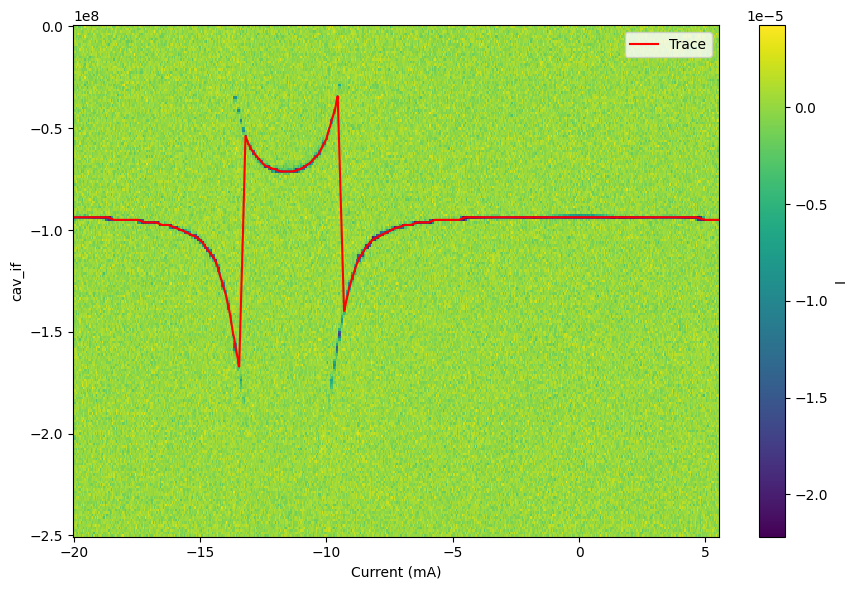

In [23]:
import numpy as np
from scipy.ndimage import uniform_filter1d
from scipy.interpolate import PchipInterpolator

def find_column_candidates(col, y_values, threshold):
    below = col < threshold
    if not below.any():
        return np.array([]), np.array([])
    edges = np.diff(below.astype(int))
    starts = np.where(edges == 1)[0] + 1
    ends = np.where(edges == -1)[0] + 1
    if below[0]:
        starts = np.r_[0, starts]
    if below[-1]:
        ends = np.r_[ends, len(below)]
    cand_y, cand_val = [], []
    for s, e in zip(starts, ends):
        seg = col[s:e]
        local_idx = s + np.argmin(seg)
        cand_y.append(y_values[local_idx])
        cand_val.append(col[local_idx])
    return np.array(cand_y), np.array(cand_val)


def extract_single_trace(x_values, y_values, data_2d, threshold=-0.5e-5,
                          seed_idx=0, half_window=6, jump_multiplier=8, smooth_size=5):
    n_curr = len(x_values)
    trace = np.full(n_curr, np.nan)

    cand_y, cand_val = find_column_candidates(data_2d[seed_idx, :], y_values, threshold)
    if len(cand_y) == 0:
        raise ValueError("No signal found at seed_idx — pick a different column.")
    trace[seed_idx] = cand_y[np.argmin(cand_val)]

    def track_direction(indices):
        prev = trace[seed_idx]
        for i in indices:
            cand_y, cand_val = find_column_candidates(data_2d[i, :], y_values, threshold)
            if len(cand_y) == 0:
                continue
            best = np.argmin(np.abs(cand_y - prev))   # closest candidate to previous point
            trace[i] = cand_y[best]
            prev = cand_y[best]

    track_direction(range(seed_idx - 1, -1, -1))
    track_direction(range(seed_idx + 1, n_curr))

    valid = ~np.isnan(trace)
    if (~valid).sum() > 0 and valid.sum() > 1:
        trace[~valid] = np.interp(x_values[~valid], x_values[valid], trace[valid])

    step_diff = np.abs(np.diff(trace))
    typical_step = np.median(step_diff)
    jump_thr = jump_multiplier * typical_step if typical_step > 0 else np.inf
    jump_indices = np.where(step_diff > jump_thr)[0]

    trace_d = trace.copy()
    for j in jump_indices:
        lo, hi = max(0, j - half_window), min(n_curr, j + half_window + 1)
        trace_d[lo:hi] = np.nan
    valid2 = ~np.isnan(trace_d)
    if (~valid2).sum() > 0 and valid2.sum() > 1:
        pchip = PchipInterpolator(x_values[valid2], trace_d[valid2])
        trace_d[~valid2] = pchip(x_values[~valid2])

    return uniform_filter1d(trace_d, size=smooth_size)


# --- Usage ---
threshold = -0.5e-5
seed_idx = 0

trace = extract_single_trace(x_values, y_values, data_2d, threshold=threshold, seed_idx=seed_idx)

import matplotlib.pyplot as plt
plt.figure(figsize=(9, 6))
plt.pcolormesh(x_values * 1e3, y_values, data_2d.T, shading="auto", cmap="viridis")
plt.plot(x_values * 1e3, trace, 'r-', linewidth=1.5, label="Trace")
plt.xlabel("Current (mA)")
plt.ylabel("cav_if")
plt.legend()
plt.colorbar(label="I")
plt.tight_layout()
plt.show()

In [24]:
np.savez("extracted_trace.npz", current_mA=x_values * 1e3, cav_if_trace=trace)


In [27]:
print("Actual length of cav_if_trace in memory:", len(cav_if_trace))
print("Actual length of current_mA_trace in memory:", len(current_mA_trace))

Actual length of cav_if_trace in memory: 511
Actual length of current_mA_trace in memory: 511


In [25]:
data = np.load("extracted_trace.npz")
current_mA_trace = data["current_mA"]
cav_if_trace = data["cav_if_trace"]

In [28]:
print("current_mA_trace = np.array([")
print(", ".join(f"{v:.6f}" for v in current_mA_trace * 1e3))
print("])")

print("\ncav_if_trace = np.array([")
print(", ".join(f"{v:.6e}" for v in cav_if_trace))
print("])")

current_mA_trace = np.array([
-20000.000000, -19950.000000, -19900.000000, -19850.000000, -19800.000000, -19750.000000, -19700.000000, -19650.000000, -19600.000000, -19550.000000, -19500.000000, -19450.000000, -19400.000000, -19350.000000, -19300.000000, -19250.000000, -19200.000000, -19150.000000, -19100.000000, -19050.000000, -19000.000000, -18950.000000, -18900.000000, -18850.000000, -18800.000000, -18750.000000, -18700.000000, -18650.000000, -18600.000000, -18550.000000, -18500.000000, -18450.000000, -18400.000000, -18350.000000, -18300.000000, -18250.000000, -18200.000000, -18150.000000, -18100.000000, -18050.000000, -18000.000000, -17950.000000, -17900.000000, -17850.000000, -17800.000000, -17750.000000, -17700.000000, -17650.000000, -17600.000000, -17550.000000, -17500.000000, -17450.000000, -17400.000000, -17350.000000, -17300.000000, -17250.000000, -17200.000000, -17150.000000, -17100.000000, -17050.000000, -17000.000000, -16950.000000, -16900.000000, -16850.000000, -16800.000